# Чекпоинт 5: экспериенты

В данном чекпоинте была устранена утечка данных из предыдущих чекпоинтов, затем проведены эксперименты, включающие в себя использования трансформеров, RNN, CNN, LSTM и регрессии. Сравнили результаты со стратегией buy & hold и simpleLSTM из бейзлайна

# Эксперименты: качество модели (1 мин), горизонт 15 минут, triple-barrier и регрессия

**Нумерация стратегий (части A–B):** **№1 — SimpleLSTM** (эталон, без утечки, веса классов + early stopping) → **№2 — Buy & Hold** (пассивная, не обучается) → **№3–№6** — LogisticRegression, RandomForest, мультиактивная LSTM, Transformer. Сравнение scaler **с утечкой / без** — только в начале (демонстрация), далее все эксперименты на **честных** данных.

## 0. Утечка данных

Если `StandardScaler` обучить на **объединении** train+val+test, в параметры масштабирования попадает информация из будущих относительно обучения наблюдений — метрики на val/test завышаются.

**Дальше в ноутбуке:** 

(1) после выборки признаков BTC — **короткая численная демонстрация** на табличной модели (LogisticRegression на агрегатах окон); 

(2) затем **все** шаги только с `fit` на train. Подбор порога по вероятности — на **val**, итог — на **test**.

## 1. Импорты и конфигурация

Ввиду ограниченности ресурсов (oom по VRAM) приходилось использовать такого рода блокеры (хот фикс можно сказать) + уменьшение батча 

In [1]:
import torch
torch.cuda.set_per_process_memory_fraction(0.85, 0) 

In [ ]:
from pathlib import Path
import os
import sys
import gc
import pickle
import ast
import warnings

# Меньше фрагментации VRAM (задать до import torch)
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

from IPython.display import display

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import math

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    mean_squared_error,
    mean_absolute_error,
)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from torch.utils.data import DataLoader, Dataset

ROOT = Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from app.ml_model import SimpleLSTM

DATA_DIR = Path(os.environ.get("ML_DATA_DIR", ROOT / "data" / "processed"))

ACTIVE_ASSET = "BTC"
WINDOW_SIZE = 60
BATCH_SIZE = 256

BATCH_SIZE_HEAVY = min(BATCH_SIZE, 128)
LR = 1e-3
EPOCHS = 30
PATIENCE = 5
HIDDEN_SIZE = 64
NUM_LAYERS = 1
DROPOUT = 0.2
SEED = 42

# Годовая частота для Sharpe: минутные шаги (часть A)
PER_YEAR_1M = 60 * 24 * 365
# Для 15-минутной доходности: столько 15-минутных интервалов в году (часть B)
PER_YEAR_15M = (60 * 24 * 365) / 15

np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.cuda.set_per_process_memory_fraction(0.92)

,device,DATA_DIR,BATCH_SIZE_HEAVY
0,cuda,/home/dima/Desktop/myrepo/master-coursework/da...,128


## 2. Вспомогательные функции и классы

In [3]:
def load_splits(data_dir: Path):
    return (
        pd.read_parquet(data_dir / "X_train.parquet"),
        pd.read_parquet(data_dir / "y_train.parquet"),
        pd.read_parquet(data_dir / "X_val.parquet"),
        pd.read_parquet(data_dir / "y_val.parquet"),
        pd.read_parquet(data_dir / "X_test.parquet"),
        pd.read_parquet(data_dir / "y_test.parquet"),
    )


def resolve_y_column(df: pd.DataFrame, asset: str, name: str = "y_bin"):
    """Parquet может отдавать MultiIndex колонками-строками вида "('BTC', 'y_bin')"."""
    key = (asset, name)
    if key in df.columns:
        return key
    for c in df.columns:
        if c == key:
            return c
        if isinstance(c, str) and c.startswith("("):
            try:
                if ast.literal_eval(c) == key:
                    return c
            except (ValueError, SyntaxError):
                pass
    raise KeyError(f"Нет таргета {key}. Примеры колонок: {list(df.columns)[:10]}")


class WindowDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray, window: int):
        self.window = window
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int64)
        self.sequences = []
        self.labels = []
        for i in range(window, len(X)):
            self.sequences.append(self.X[i - window : i])
            self.labels.append(self.y[i])
        self.sequences = np.stack(self.sequences, axis=0)
        self.labels = np.array(self.labels, dtype=np.int64)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.from_numpy(self.sequences[idx]),
            torch.tensor(self.labels[idx], dtype=torch.long),
        )


def sharpe_ratio(log_returns, periods_per_year: float):
    if len(log_returns) == 0 or log_returns.std() == 0:
        return 0.0
    return float(log_returns.mean() / log_returns.std() * np.sqrt(periods_per_year))


@torch.no_grad()
def roc_auc_logits(model, loader):
    model.eval()
    ys, scores = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        logit = model(xb)[:, 1].cpu().numpy()
        ys.append(yb.numpy())
        scores.append(logit)
    if not ys:
        return 0.5
    y = np.concatenate(ys)
    s = np.concatenate(scores)
    try:
        return roc_auc_score(y, s)
    except ValueError:
        return 0.5


def train_epoch(model, loader, criterion, optimizer):
    model.train()
    tot, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        tot += loss.item() * xb.size(0)
        n += xb.size(0)
    return tot / max(n, 1)


@torch.no_grad()
def predict_labels_probs(model, loader):
    model.eval()
    preds, ys, probs = [], [], []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        p = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        pr = torch.argmax(logits, dim=1).cpu().numpy()
        preds.append(pr)
        ys.append(yb.numpy())
        probs.append(p)
    return (
        np.concatenate(preds),
        np.concatenate(ys),
        np.concatenate(probs),
    )


def aggregate_windows(X: np.ndarray, y: np.ndarray, window: int):
    """Из (N, features) → (N-window, агрегаты по окну)."""
    rows, labels = [], []
    for i in range(window, len(X)):
        w = X[i - window : i]
        agg = np.concatenate([w.mean(0), w.std(0), w.min(0), w.max(0), w[-1]])
        rows.append(agg)
        labels.append(y[i])
    return np.array(rows, dtype=np.float32), np.array(labels, dtype=np.int64)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=512):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, : x.size(1)])


class TransformerClassifier(nn.Module):
    def __init__(self, input_size, d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.fc = nn.Linear(d_model, 2)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_enc(x)
        x = self.encoder(x)
        x = self.norm(x[:, -1, :])
        return self.fc(x)


class SimpleLSTMReg(nn.Module):
    # Один выход: регрессия на непрерывный таргет

    def __init__(self, input_size, hidden_size=64, num_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.dropout(out[:, -1, :]))


class WindowDatasetReg(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray, window: int):
        self.window = window
        self.X = X.astype(np.float32)
        self.y = y.astype(np.float32)
        self.sequences = []
        self.labels = []
        for i in range(window, len(X)):
            self.sequences.append(self.X[i - window : i])
            self.labels.append(self.y[i])
        self.sequences = np.stack(self.sequences, axis=0)
        self.labels = np.array(self.labels, dtype=np.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.from_numpy(self.sequences[idx]),
            torch.tensor(self.labels[idx], dtype=torch.float32),
        )


def triple_barrier_labels(
    r: pd.Series,
    vol_window: int,
    pt_mult: float,
    sl_mult: float,
    vertical: int,
    eps: float = 1e-8,
) -> pd.Series:
    """Бинарная метка по тройному барьеру (упрощённо, López de Prado):
    1 — первым достигнут верхний барьер (take-profit в единицах волатильности);
    0 — первым нижний (stop) или истекло `vertical` минут без верхнего бара.
    Волатильность на шаге i: std минутных log-returns на [i-vol_window, i).
    Вперёд смотрим ровно `vertical` минутных доходностей, начиная с r[i].
    """
    r = r.astype(float).sort_index()
    vals = r.values
    n = len(vals)
    out = np.full(n, np.nan)
    for pos in range(vol_window, n - vertical + 1):
        sig = float(vals[pos - vol_window : pos].std())
        if sig < eps:
            sig = eps
        upper = pt_mult * sig
        lower = -sl_mult * sig
        cum = 0.0
        lab = 0
        for k in range(vertical):
            cum += vals[pos + k]
            if cum >= upper:
                lab = 1
                break
            if cum <= lower:
                lab = 0
                break
        else:
            lab = 0
        out[pos] = lab
    return pd.Series(out, index=r.index)


def train_epoch_reg(model, loader, criterion, optimizer):
    model.train()
    tot, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device).unsqueeze(1)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        tot += loss.item() * xb.size(0)
        n += xb.size(0)
    return tot / max(n, 1)


@torch.no_grad()
def predict_reg(model, loader):
    model.eval()
    preds, ys = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        p = model(xb).squeeze(1).cpu().numpy()
        preds.append(p)
        ys.append(yb.numpy())
    return np.concatenate(preds), np.concatenate(ys)


@torch.no_grad()
def eval_mse_reg(model, loader):
    model.eval()
    tot, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device).unsqueeze(1)
        pred = model(xb)
        tot += ((pred - yb) ** 2).sum().item()
        n += xb.size(0)
    return tot / max(n, 1)

## 3. Загрузка parquet (train / val / test)

In [4]:
X_train, y_train, X_val, y_val, X_test, y_test = load_splits(DATA_DIR)
display(pd.DataFrame([{"X_train": str(X_train.shape), "X_val": str(X_val.shape), "X_test": str(X_test.shape)}]))

,X_train,X_val,X_test
0,"(348481, 72)","(175680, 77)","(393120, 72)"


---

# Часть A. Горизонт 1 минута (`y_bin` / `y_reg`)

| № | Стратегия |
|---|-----------|
| 1 | **SimpleLSTM** — эталон (веса классов + early stopping по val ROC-AUC), без утечки |
| 2 | **Buy & Hold** — пассивная |
| 3 | LogisticRegression (агрегаты окон) |
| 4 | RandomForest |
| 5 | Мультиактивная LSTM |
| 6 | TransformerClassifier |

Порядок: признаки BTC → демонстрация утечки scaler → честный scaler и датасеты → стратегии №1–№6 → сводные таблицы и графики по активам.

### A.1. Признаки BTC и таргет `y_bin`

In [5]:
prefix = f"{ACTIVE_ASSET}__"
feat_cols = [c for c in X_train.columns if str(c).startswith(prefix)]
if not feat_cols:
    raise ValueError(f"Нет колонок с префиксом {prefix}")

y_col = resolve_y_column(y_train, ACTIVE_ASSET, "y_bin")

Xt = X_train[feat_cols]
Xv = X_val[feat_cols]
Xte = X_test[feat_cols]

yt = y_train[y_col].dropna()
yv = y_val[resolve_y_column(y_val, ACTIVE_ASSET, "y_bin")].dropna()
yte = y_test[resolve_y_column(y_test, ACTIVE_ASSET, "y_bin")].dropna()

Xt = Xt.loc[yt.index]
Xv = Xv.loc[yv.index]
Xte = Xte.loc[yte.index]

n_features = len(feat_cols)
display(
    pd.DataFrame(
        [{"n_features": n_features, "rows_train": len(Xt), "rows_val": len(Xv), "rows_test": len(Xte)}]
    )
)

,n_features,rows_train,rows_val,rows_test
0,14,348481,175680,393120


### A.2. `StandardScaler`

In [7]:
scaler = StandardScaler()
Xt_s = scaler.fit_transform(Xt)
Xv_s = scaler.transform(Xv)
Xte_s = scaler.transform(Xte)

yt_a = yt.values.astype(np.int64)
yv_a = yv.values.astype(np.int64)
yte_a = yte.values.astype(np.int64)

### A.3. Датасеты и загрузчики

In [8]:
train_ds = WindowDataset(Xt_s, yt_a, WINDOW_SIZE)
val_ds = WindowDataset(Xv_s, yv_a, WINDOW_SIZE)
test_ds = WindowDataset(Xte_s, yte_a, WINDOW_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

counts = np.bincount(train_ds.labels, minlength=2)
w = counts.sum() / (2 * np.maximum(counts, 1))
class_weights = torch.tensor(w, dtype=torch.float32)
display(pd.DataFrame([{"train_windows": len(train_ds), "class_counts": counts.tolist(), "class_weights": w.tolist()}]))

,train_windows,class_counts,class_weights
0,348421,"[179101, 169320]","[0.9726941781452924, 1.0288831797779352]"


### Стратегия №1 — SimpleLSTM (эталон: веса классов + early stopping по val ROC-AUC)

In [ ]:
model = SimpleLSTM(
    input_size=n_features,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=LR)

best_auc = -1.0
best_state = None
stale = 0

for epoch in range(1, EPOCHS + 1):
    tr_loss = train_epoch(model, train_loader, criterion, optimizer)
    val_auc = roc_auc_logits(model, val_loader)
    print(f"epoch {epoch:02d}/{EPOCHS}  train_loss={tr_loss:.4f}  val_roc_auc={val_auc:.4f}")
    if val_auc > best_auc:
        best_auc = val_auc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        stale = 0
    else:
        stale += 1
        if stale >= PATIENCE:
            print(f"early stopping ({PATIENCE} epochs без роста val AUC)")
            break

if best_state is not None:
    model.load_state_dict(best_state)
    
print()
print(f"best_val_roc_auc = {best_auc}")

epoch 01/30  train_loss=0.6920  val_roc_auc=0.5100
epoch 02/30  train_loss=0.6914  val_roc_auc=0.5027
epoch 03/30  train_loss=0.6913  val_roc_auc=0.5110
epoch 04/30  train_loss=0.6911  val_roc_auc=0.5130
epoch 05/30  train_loss=0.6910  val_roc_auc=0.5124
epoch 06/30  train_loss=0.6911  val_roc_auc=0.5087
epoch 07/30  train_loss=0.6910  val_roc_auc=0.5142
epoch 08/30  train_loss=0.6908  val_roc_auc=0.5086
epoch 09/30  train_loss=0.6906  val_roc_auc=0.5100
epoch 10/30  train_loss=0.6907  val_roc_auc=0.5088
epoch 11/30  train_loss=0.6906  val_roc_auc=0.5126
epoch 12/30  train_loss=0.6905  val_roc_auc=0.5084
early stopping (5 epochs без роста val AUC)


,best_val_roc_auc
0,0.514244


#### Метрики на test (порог argmax ~0.5) — стратегия №1

Число окон на test — в строке «Окон на test»; далее таблица метрик и матрица ошибок.

In [10]:
pred, y_true, p1 = predict_labels_probs(model, test_loader)

acc = accuracy_score(y_true, pred)
prec = precision_score(y_true, pred, zero_division=0)
rec = recall_score(y_true, pred, zero_division=0)
f1 = f1_score(y_true, pred, zero_division=0)
auc = roc_auc_score(y_true, p1)

metrics_new = [
    ("Окон на test", len(y_true)),
    ("Accuracy", acc),
    ("Precision", prec),
    ("Recall", rec),
    ("F1", f1),
    ("ROC-AUC", auc),
]
metrics_new_df = pd.DataFrame(metrics_new, columns=["Метрика", "Значение (порог 0.5)"])
display(metrics_new_df)
cm = confusion_matrix(y_true, pred)
display(pd.DataFrame(cm, index=["true 0", "true 1"], columns=["pred 0", "pred 1"]))

,Метрика,Значение (порог 0.5)
0,Окон на test,393060.000000
1,Accuracy,0.519198
2,Precision,0.510074
3,Recall,0.034248
4,F1,0.064185
5,ROC-AUC,0.526203


,pred 0,pred 1
true 0,197595,6225
true 1,182759,6481


#### Стратегия №1 (продолжение): подбор порога на val (F1) и применение на test

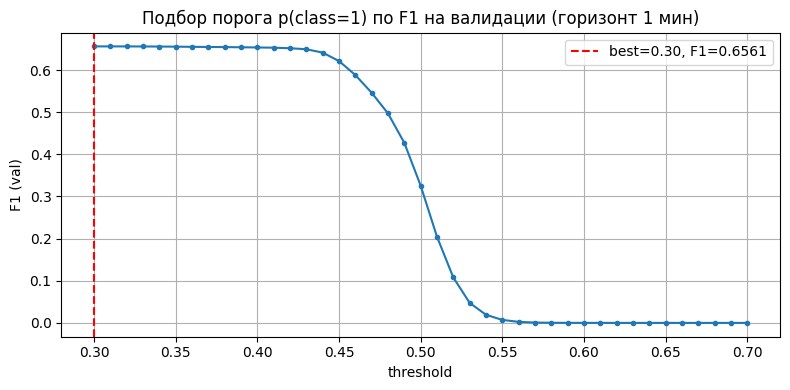

,Метрика,Порог argmax (0.5),Оптимальный порог (0.30)
0,Accuracy,0.519198,0.481486
1,Precision,0.510074,0.481469
2,Recall,0.034248,0.999968
3,F1,0.064185,0.649982
4,ROC-AUC,0.526203,0.526203


,pred 0,pred 1
true 0,19,203801
true 1,6,189234


In [11]:
val_pred, val_true, val_p1 = predict_labels_probs(model, val_loader)

thresholds = np.arange(0.30, 0.71, 0.01)
f1_scores = []
for t in thresholds:
    preds_t = (val_p1 >= t).astype(int)
    f1_scores.append(f1_score(val_true, preds_t, zero_division=0))

best_idx = int(np.argmax(f1_scores))
best_threshold = thresholds[best_idx]
best_f1_val = f1_scores[best_idx]

plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores, marker=".")
plt.axvline(
    best_threshold,
    color="red",
    ls="--",
    label=f"best={best_threshold:.2f}, F1={best_f1_val:.4f}",
)
plt.xlabel("threshold")
plt.ylabel("F1 (val)")
plt.title("Подбор порога p(class=1) по F1 на валидации (горизонт 1 мин)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

test_pred_tuned = (p1 >= best_threshold).astype(int)

metrics_df = pd.DataFrame(
    [
        ("Accuracy", accuracy_score(y_true, pred), accuracy_score(y_true, test_pred_tuned)),
        ("Precision", precision_score(y_true, pred, zero_division=0), precision_score(y_true, test_pred_tuned, zero_division=0)),
        ("Recall", recall_score(y_true, pred, zero_division=0), recall_score(y_true, test_pred_tuned, zero_division=0)),
        ("F1", f1_score(y_true, pred, zero_division=0), f1_score(y_true, test_pred_tuned, zero_division=0)),
        ("ROC-AUC", roc_auc_score(y_true, p1), roc_auc_score(y_true, p1)),
    ],
    columns=["Метрика", "Порог argmax (0.5)", f"Оптимальный порог ({best_threshold:.2f})"],
)
display(metrics_df)
cm_t = confusion_matrix(y_true, test_pred_tuned)
display(pd.DataFrame(cm_t, index=["true 0", "true 1"], columns=["pred 0", "pred 1"]))

### Стратегия №2 — Buy & Hold

Пассивная стратегия: доходность актива без торговых сигналов модели. Sharpe и кумулятивная доходность по минутной `y_reg` на том же выровненном test-интервале, что и для №1.

,Стратегия,Sharpe Ratio (Annualized)
0,#2 Buy & Hold,0.633331
1,#1 SimpleLSTM (argmax),2.512878
2,#1 SimpleLSTM (t=0.30),0.633578


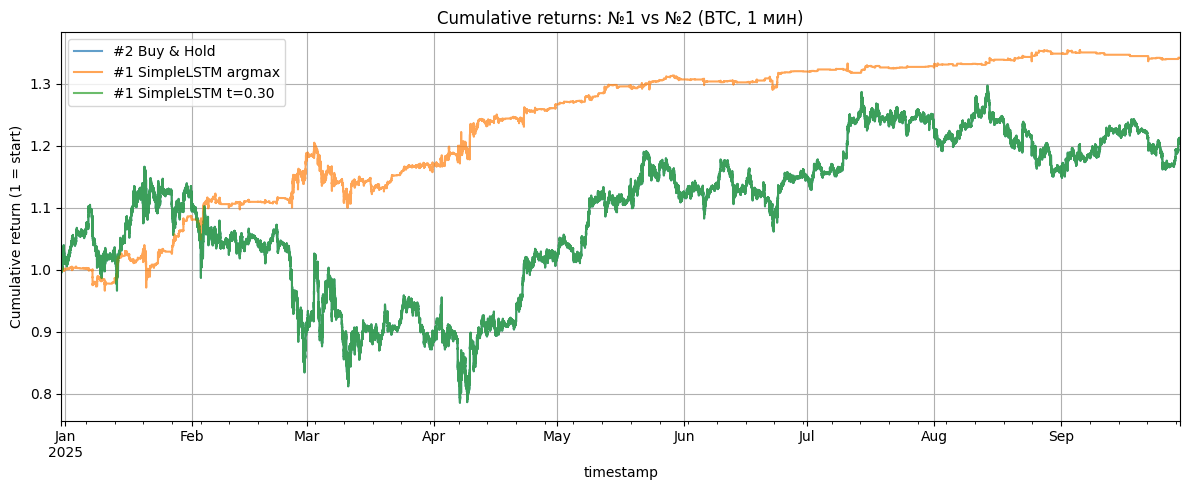

In [12]:
y_reg_col = resolve_y_column(y_test, ACTIVE_ASSET, "y_reg")
y_reg_test = y_test[y_reg_col].dropna()

test_indices = Xte.index[WINDOW_SIZE:]
common = test_indices.intersection(y_reg_test.index)
actual_returns = y_reg_test.loc[common]

offset = len(test_indices) - len(common)
preds_argmax = pred[offset:]
preds_tuned = test_pred_tuned[offset:]

strategy_returns_argmax = pd.Series(preds_argmax, index=common) * actual_returns
strategy_returns_tuned = pd.Series(preds_tuned, index=common) * actual_returns

bh_sharpe = sharpe_ratio(actual_returns, PER_YEAR_1M)
strat_sharpe_argmax = sharpe_ratio(strategy_returns_argmax, PER_YEAR_1M)
strat_sharpe_tuned = sharpe_ratio(strategy_returns_tuned, PER_YEAR_1M)

sharpe_df = pd.DataFrame(
    [
        ("#2 Buy & Hold", bh_sharpe),
        ("#1 SimpleLSTM (argmax)", strat_sharpe_argmax),
        (f"#1 SimpleLSTM (t={best_threshold:.2f})", strat_sharpe_tuned),
    ],
    columns=["Стратегия", "Sharpe Ratio (Annualized)"],
)
display(sharpe_df)

fig, ax = plt.subplots(figsize=(12, 5))
(actual_returns.cumsum() + 1).plot(ax=ax, label="#2 Buy & Hold", alpha=0.7)
(strategy_returns_argmax.cumsum() + 1).plot(ax=ax, label="#1 SimpleLSTM argmax", alpha=0.7)
(strategy_returns_tuned.cumsum() + 1).plot(ax=ax, label=f"#1 SimpleLSTM t={best_threshold:.2f}", alpha=0.7)
ax.set_title(f"Cumulative returns: №1 vs №2 ({ACTIVE_ASSET}, 1 мин)")
ax.set_ylabel("Cumulative return (1 = start)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

### Стратегии №3 и №4 — Logistic Regression и Random Forest

Агрегаты по окну (mean, std, min, max, последнее значение) → модель; используется честный `Xt_s`.

In [13]:
Xt_agg, yt_agg = aggregate_windows(Xt_s, yt_a, WINDOW_SIZE)
Xv_agg, yv_agg = aggregate_windows(Xv_s, yv_a, WINDOW_SIZE)
Xte_agg, yte_agg = aggregate_windows(Xte_s, yte_a, WINDOW_SIZE)

lr_model = LogisticRegression(max_iter=500, class_weight="balanced", random_state=SEED)
lr_model.fit(Xt_agg, yt_agg)
lr_probs = lr_model.predict_proba(Xte_agg)[:, 1]
lr_preds = lr_model.predict(Xte_agg)
lr_auc = roc_auc_score(yte_agg, lr_probs)
lr_f1 = f1_score(yte_agg, lr_preds, zero_division=0)

rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=8, class_weight="balanced", random_state=SEED, n_jobs=-1
)
rf_model.fit(Xt_agg, yt_agg)
rf_probs = rf_model.predict_proba(Xte_agg)[:, 1]
rf_preds = rf_model.predict(Xte_agg)
rf_auc = roc_auc_score(yte_agg, rf_probs)
rf_f1 = f1_score(yte_agg, rf_preds, zero_division=0)

res_tab = pd.DataFrame(
    [
        ("#3 LogisticRegression", lr_auc, lr_f1),
        ("#4 RandomForest", rf_auc, rf_f1),
        ("#1 SimpleLSTM (argmax)", roc_auc_score(y_true, p1), f1_score(y_true, pred, zero_division=0)),
        ("#1 SimpleLSTM (tuned)", roc_auc_score(y_true, p1), f1_score(y_true, test_pred_tuned, zero_division=0)),
    ],
    columns=["Стратегия", "ROC-AUC", "F1"],
)
display(res_tab)

,Стратегия,ROC-AUC,F1
0,#3 LogisticRegression,0.524916,0.143539
1,#4 RandomForest,0.526772,0.187377
2,#1 SimpleLSTM (argmax),0.526203,0.064185
3,#1 SimpleLSTM (tuned),0.526203,0.649982


### Стратегия №5 — мультиактивная LSTM (5 активов, метка `y_bin`)

In [ ]:
ASSETS = ["BTC", "ETH", "BNB", "SOL", "XRP"]

multi_train_X, multi_train_y = [], []
multi_val_X, multi_val_y = [], []

for asset in ASSETS:
    a_prefix = f"{asset}__"
    a_feat = [c for c in X_train.columns if str(c).startswith(a_prefix)]
    if not a_feat:
        continue

    a_ycol = resolve_y_column(y_train, asset, "y_bin")
    a_yt = y_train[a_ycol].dropna()
    a_Xt = X_train[a_feat].loc[a_yt.index]

    a_ycol_v = resolve_y_column(y_val, asset, "y_bin")
    a_yv = y_val[a_ycol_v].dropna()
    a_Xv = X_val[a_feat].loc[a_yv.index]

    multi_train_X.append(a_Xt.values)
    multi_train_y.append(a_yt.values)
    multi_val_X.append(a_Xv.values)
    multi_val_y.append(a_yv.values)

multi_Xt = np.concatenate(multi_train_X, axis=0)
multi_yt = np.concatenate(multi_train_y, axis=0).astype(np.int64)
multi_Xv = np.concatenate(multi_val_X, axis=0)
multi_yv = np.concatenate(multi_val_y, axis=0).astype(np.int64)
del multi_train_X, multi_val_X, multi_train_y, multi_val_y

multi_scaler = StandardScaler()
multi_Xt_s = multi_scaler.fit_transform(multi_Xt)
multi_Xv_s = multi_scaler.transform(multi_Xv)
del multi_Xt, multi_Xv
gc.collect()

multi_train_ds = WindowDataset(multi_Xt_s, multi_yt, WINDOW_SIZE)
multi_val_ds = WindowDataset(multi_Xv_s, multi_yv, WINDOW_SIZE)
multi_train_loader = DataLoader(multi_train_ds, batch_size=BATCH_SIZE_HEAVY, shuffle=True)
multi_val_loader = DataLoader(multi_val_ds, batch_size=BATCH_SIZE_HEAVY, shuffle=False)

multi_counts = np.bincount(multi_train_ds.labels, minlength=2)
multi_w = multi_counts.sum() / (2 * np.maximum(multi_counts, 1))
multi_cw = torch.tensor(multi_w, dtype=torch.float32)

multi_model = SimpleLSTM(
    input_size=n_features,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(device)

multi_criterion = nn.CrossEntropyLoss(weight=multi_cw.to(device))
multi_optimizer = optim.Adam(multi_model.parameters(), lr=LR)

m_best_auc = -1.0
m_best_state = None
m_stale = 0

for epoch in range(1, EPOCHS + 1):
    tr_loss = train_epoch(multi_model, multi_train_loader, multi_criterion, multi_optimizer)
    val_auc = roc_auc_logits(multi_model, multi_val_loader)
    print(f"epoch {epoch:02d}/{EPOCHS}  train_loss={tr_loss:.4f}  val_roc_auc={val_auc:.4f}")
    if val_auc > m_best_auc:
        m_best_auc = val_auc
        m_best_state = {k: v.cpu().clone() for k, v in multi_model.state_dict().items()}
        m_stale = 0
    else:
        m_stale += 1
        if m_stale >= PATIENCE:
            print(f"early stopping ({PATIENCE} эпох без роста)")
            break

if m_best_state is not None:
    multi_model.load_state_dict(m_best_state)

del multi_train_loader, multi_val_loader, multi_train_ds, multi_val_ds
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

multi_Xte_s = multi_scaler.transform(Xte)
multi_test_ds = WindowDataset(multi_Xte_s, yte_a, WINDOW_SIZE)
multi_test_loader = DataLoader(multi_test_ds, batch_size=BATCH_SIZE_HEAVY, shuffle=False)

m_pred, m_true, m_p1 = predict_labels_probs(multi_model, multi_test_loader)

btc_val_Xs = multi_scaler.transform(Xv)
btc_val_ds = WindowDataset(btc_val_Xs, yv_a, WINDOW_SIZE)
btc_val_loader = DataLoader(btc_val_ds, batch_size=BATCH_SIZE_HEAVY, shuffle=False)
m_val_pred, m_val_true, m_val_p1 = predict_labels_probs(multi_model, btc_val_loader)

m_f1s = [f1_score(m_val_true, (m_val_p1 >= t).astype(int), zero_division=0) for t in thresholds]
m_best_t = thresholds[int(np.argmax(m_f1s))]
m_test_tuned = (m_p1 >= m_best_t).astype(int)

# Индексы окон test совпадают с Xte.index[WINDOW_SIZE:] (длина = len(m_test_tuned)); common короче из-за intersection
_idx_test_win = Xte.index[WINDOW_SIZE : WINDOW_SIZE + len(m_test_tuned)]
m_strat_tuned = pd.Series(m_test_tuned, index=_idx_test_win) * y_reg_test.reindex(_idx_test_win).fillna(0.0)

display(
    pd.DataFrame(
        [
            ("ROC-AUC", roc_auc_score(m_true, m_p1)),
            ("F1 (argmax)", f1_score(m_true, m_pred, zero_division=0)),
            (f"F1 (tuned t={m_best_t:.2f})", f1_score(m_true, m_test_tuned, zero_division=0)),
        ],
        columns=["Метрика", "Значение"],
    )
)

epoch 01/30  train_loss=0.6903  val_roc_auc=0.5301
epoch 02/30  train_loss=0.6898  val_roc_auc=0.5287
epoch 03/30  train_loss=0.6896  val_roc_auc=0.5308
epoch 04/30  train_loss=0.6895  val_roc_auc=0.5312
epoch 05/30  train_loss=0.6894  val_roc_auc=0.5213
epoch 06/30  train_loss=0.6893  val_roc_auc=0.5332
epoch 07/30  train_loss=0.6892  val_roc_auc=0.5324
epoch 08/30  train_loss=0.6891  val_roc_auc=0.5315
epoch 09/30  train_loss=0.6891  val_roc_auc=0.5333
epoch 10/30  train_loss=0.6890  val_roc_auc=0.5327
epoch 11/30  train_loss=0.6890  val_roc_auc=0.5333
epoch 12/30  train_loss=0.6889  val_roc_auc=0.5329
epoch 13/30  train_loss=0.6889  val_roc_auc=0.5339
epoch 14/30  train_loss=0.6890  val_roc_auc=0.5330
epoch 15/30  train_loss=0.6888  val_roc_auc=0.5333
epoch 16/30  train_loss=0.6888  val_roc_auc=0.5327
epoch 17/30  train_loss=0.6887  val_roc_auc=0.5338
epoch 18/30  train_loss=0.6886  val_roc_auc=0.5330
early stopping (5 epochs без роста)


,Метрика,Значение
0,ROC-AUC,0.526549
1,F1 (argmax),0.518386
2,F1 (tuned t=0.33),0.650004


### Стратегия №6 — TransformerClassifier (BTC, метка `y_bin`)

epoch 01/30  train_loss=0.6934  val_roc_auc=0.5177
epoch 02/30  train_loss=0.6920  val_roc_auc=0.5195
epoch 03/30  train_loss=0.6918  val_roc_auc=0.5205
epoch 04/30  train_loss=0.6917  val_roc_auc=0.5197
epoch 05/30  train_loss=0.6917  val_roc_auc=0.5191
epoch 06/30  train_loss=0.6917  val_roc_auc=0.5195
epoch 07/30  train_loss=0.6917  val_roc_auc=0.5190
epoch 08/30  train_loss=0.6916  val_roc_auc=0.5177
early stopping (5 epochs без роста)


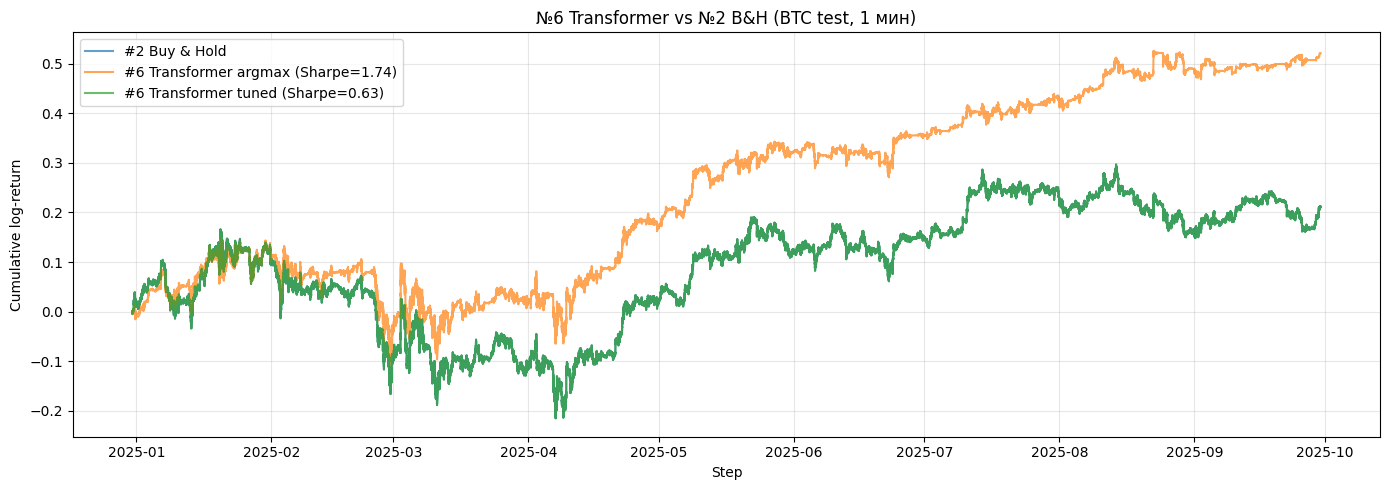

In [ ]:
TF_D_MODEL = 64
TF_NHEAD = 4
TF_NUM_LAYERS = 2
TF_DROPOUT = 0.1

torch.manual_seed(SEED)
np.random.seed(SEED)

tf_model = TransformerClassifier(
    input_size=n_features,
    d_model=TF_D_MODEL,
    nhead=TF_NHEAD,
    num_layers=TF_NUM_LAYERS,
    dropout=TF_DROPOUT,
).to(device)

tf_criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
tf_optimizer = optim.Adam(tf_model.parameters(), lr=LR)

tf_best_auc = -1.0
tf_best_state = None
tf_stale = 0

for epoch in range(1, EPOCHS + 1):
    tr_loss = train_epoch(tf_model, train_loader, tf_criterion, tf_optimizer)
    val_auc = roc_auc_logits(tf_model, val_loader)
    print(f"epoch {epoch:02d}/{EPOCHS}  train_loss={tr_loss:.4f}  val_roc_auc={val_auc:.4f}")
    if val_auc > tf_best_auc:
        tf_best_auc = val_auc
        tf_best_state = {k: v.cpu().clone() for k, v in tf_model.state_dict().items()}
        tf_stale = 0
    else:
        tf_stale += 1
        if tf_stale >= PATIENCE:
            print(f"early stopping ({PATIENCE} эпох без роста)")
            break

if tf_best_state is not None:
    tf_model.load_state_dict(tf_best_state)

tf_preds, tf_true, tf_p1 = predict_labels_probs(tf_model, test_loader)
tf_val_preds, tf_val_true, tf_val_p1 = predict_labels_probs(tf_model, val_loader)

best_t_tf, best_f1_t = 0.5, 0.0
for t in thresholds:
    preds_t = (tf_val_p1 >= t).astype(int)
    f1_t = f1_score(tf_val_true, preds_t, zero_division=0)
    if f1_t > best_f1_t:
        best_t_tf, best_f1_t = t, f1_t

tf_preds_tuned = (tf_p1 >= best_t_tf).astype(int)

tf_pa = tf_preds[offset:]
tf_pt = tf_preds_tuned[offset:]
strat_tf_argmax = pd.Series(tf_pa, index=common) * actual_returns
strat_tf_tuned = pd.Series(tf_pt, index=common) * actual_returns
sharpe_tf_argmax = sharpe_ratio(strat_tf_argmax, PER_YEAR_1M)
sharpe_tf_tuned = sharpe_ratio(strat_tf_tuned, PER_YEAR_1M)

plt.figure(figsize=(14, 5))
plt.plot(actual_returns.cumsum(), label="#2 Buy & Hold", alpha=0.7)
plt.plot(strat_tf_argmax.cumsum(), label=f"#6 Transformer argmax (Sharpe={sharpe_tf_argmax:.2f})", alpha=0.7)
plt.plot(strat_tf_tuned.cumsum(), label=f"#6 Transformer tuned (Sharpe={sharpe_tf_tuned:.2f})", alpha=0.7)
plt.title("№6 Transformer vs №2 B&H (BTC test, 1 мин)")
plt.xlabel("Step")
plt.ylabel("Cumulative log-return")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Сводная таблица: ROC-AUC, F1, Sharpe (часть A, стратегии №1–№6)

Горизонт 1 минута: сравнение стратегий по классификации и по Sharpe (годовая шкала).

In [16]:
_idx_lr = Xte.index[WINDOW_SIZE : WINDOW_SIZE + len(lr_probs)]
_ret_lr = y_reg_test.reindex(_idx_lr).fillna(0.0)
lr_strat = pd.Series((lr_probs >= 0.5).astype(int), index=_idx_lr) * _ret_lr
_idx_rf = Xte.index[WINDOW_SIZE : WINDOW_SIZE + len(rf_probs)]
_ret_rf = y_reg_test.reindex(_idx_rf).fillna(0.0)
rf_strat = pd.Series((rf_probs >= 0.5).astype(int), index=_idx_rf) * _ret_rf

all_results = [
    ("#3 LogisticRegression", lr_auc, lr_f1),
    ("#4 RandomForest", rf_auc, rf_f1),
    ("#1 SimpleLSTM (argmax)", roc_auc_score(y_true, p1), f1_score(y_true, pred, zero_division=0)),
    (f"#1 SimpleLSTM (t={best_threshold:.2f})", roc_auc_score(y_true, p1), f1_score(y_true, test_pred_tuned, zero_division=0)),
    ("#5 Multi-LSTM (argmax)", roc_auc_score(m_true, m_p1), f1_score(m_true, m_pred, zero_division=0)),
    (f"#5 Multi-LSTM (t={m_best_t:.2f})", roc_auc_score(m_true, m_p1), f1_score(m_true, m_test_tuned, zero_division=0)),
    ("#6 Transformer (argmax)", roc_auc_score(tf_true, tf_p1), f1_score(tf_true, tf_preds, zero_division=0)),
    (f"#6 Transformer (t={best_t_tf:.2f})", roc_auc_score(tf_true, tf_p1), f1_score(tf_true, tf_preds_tuned, zero_division=0)),
]

all_sharpe = [
    ("#2 Buy & Hold", bh_sharpe),
    ("#3 LogisticRegression", sharpe_ratio(lr_strat, PER_YEAR_1M)),
    ("#4 RandomForest", sharpe_ratio(rf_strat, PER_YEAR_1M)),
    ("#1 SimpleLSTM (argmax)", strat_sharpe_argmax),
    (f"#1 SimpleLSTM (t={best_threshold:.2f})", strat_sharpe_tuned),
    (f"#5 Multi-LSTM (t={m_best_t:.2f})", sharpe_ratio(m_strat_tuned, PER_YEAR_1M)),
    ("#6 Transformer (argmax)", sharpe_tf_argmax),
    (f"#6 Transformer (t={best_t_tf:.2f})", sharpe_tf_tuned),
]

df_all_results = pd.DataFrame(all_results, columns=["Стратегия", "ROC-AUC", "F1"])
df_all_sharpe = pd.DataFrame(all_sharpe, columns=["Стратегия", "Sharpe (ann.)"])

display(df_all_results)
display(df_all_sharpe)

,Стратегия,ROC-AUC,F1
0,#3 LogisticRegression,0.524916,0.143539
1,#4 RandomForest,0.526772,0.187377
2,#1 SimpleLSTM (argmax),0.526203,0.064185
3,#1 SimpleLSTM (t=0.30),0.526203,0.649982
4,#5 Multi-LSTM (argmax),0.526549,0.518386
5,#5 Multi-LSTM (t=0.33),0.526549,0.650004
6,#6 Transformer (argmax),0.527631,0.469031
7,#6 Transformer (t=0.36),0.527631,0.649974


,Стратегия,Sharpe (ann.)
0,#2 Buy & Hold,0.633331
1,#3 LogisticRegression,-0.524607
2,#4 RandomForest,0.477023
3,#1 SimpleLSTM (argmax),2.512878
4,#1 SimpleLSTM (t=0.30),0.633578
5,#5 Multi-LSTM (t=0.33),0.639812
6,#6 Transformer (argmax),1.740980
7,#6 Transformer (t=0.36),0.633331


Образовался следующий топ: 
1. SimpleLSTM (argmax)
2. Transformer (argmax)
3. SimpleLSTM (t=0.3)

### Графики по всем 5 активам (`y_bin`, `y_reg`): №1, №2, №5, №6

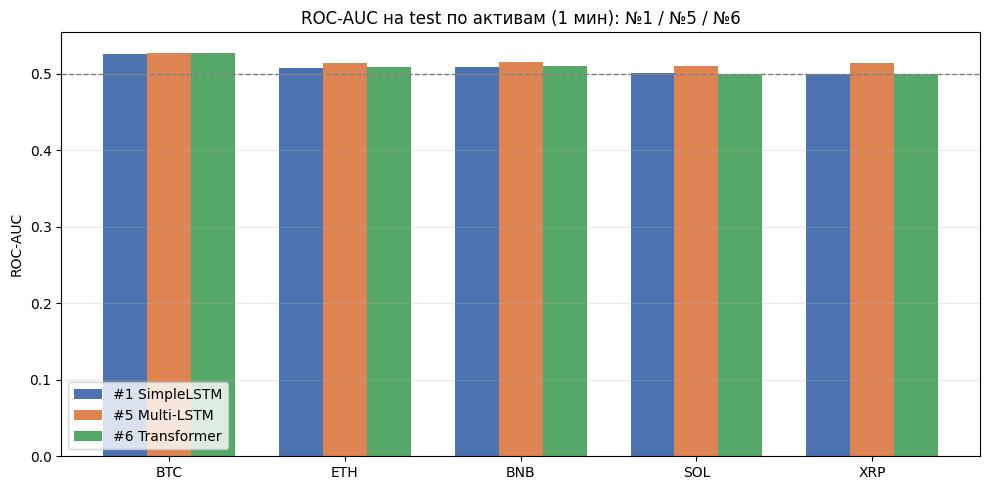

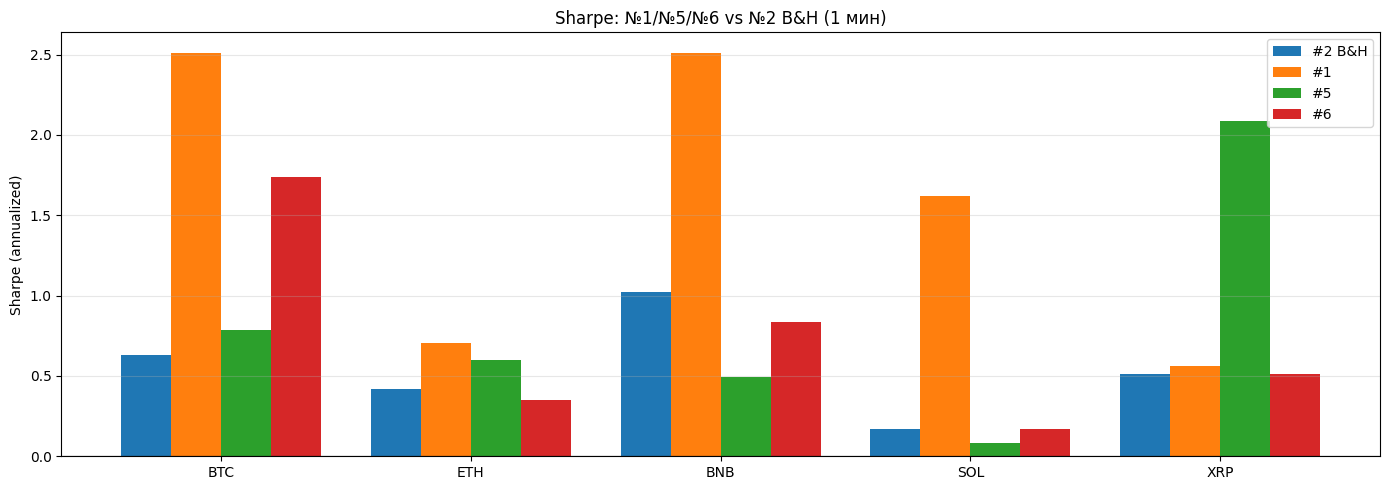

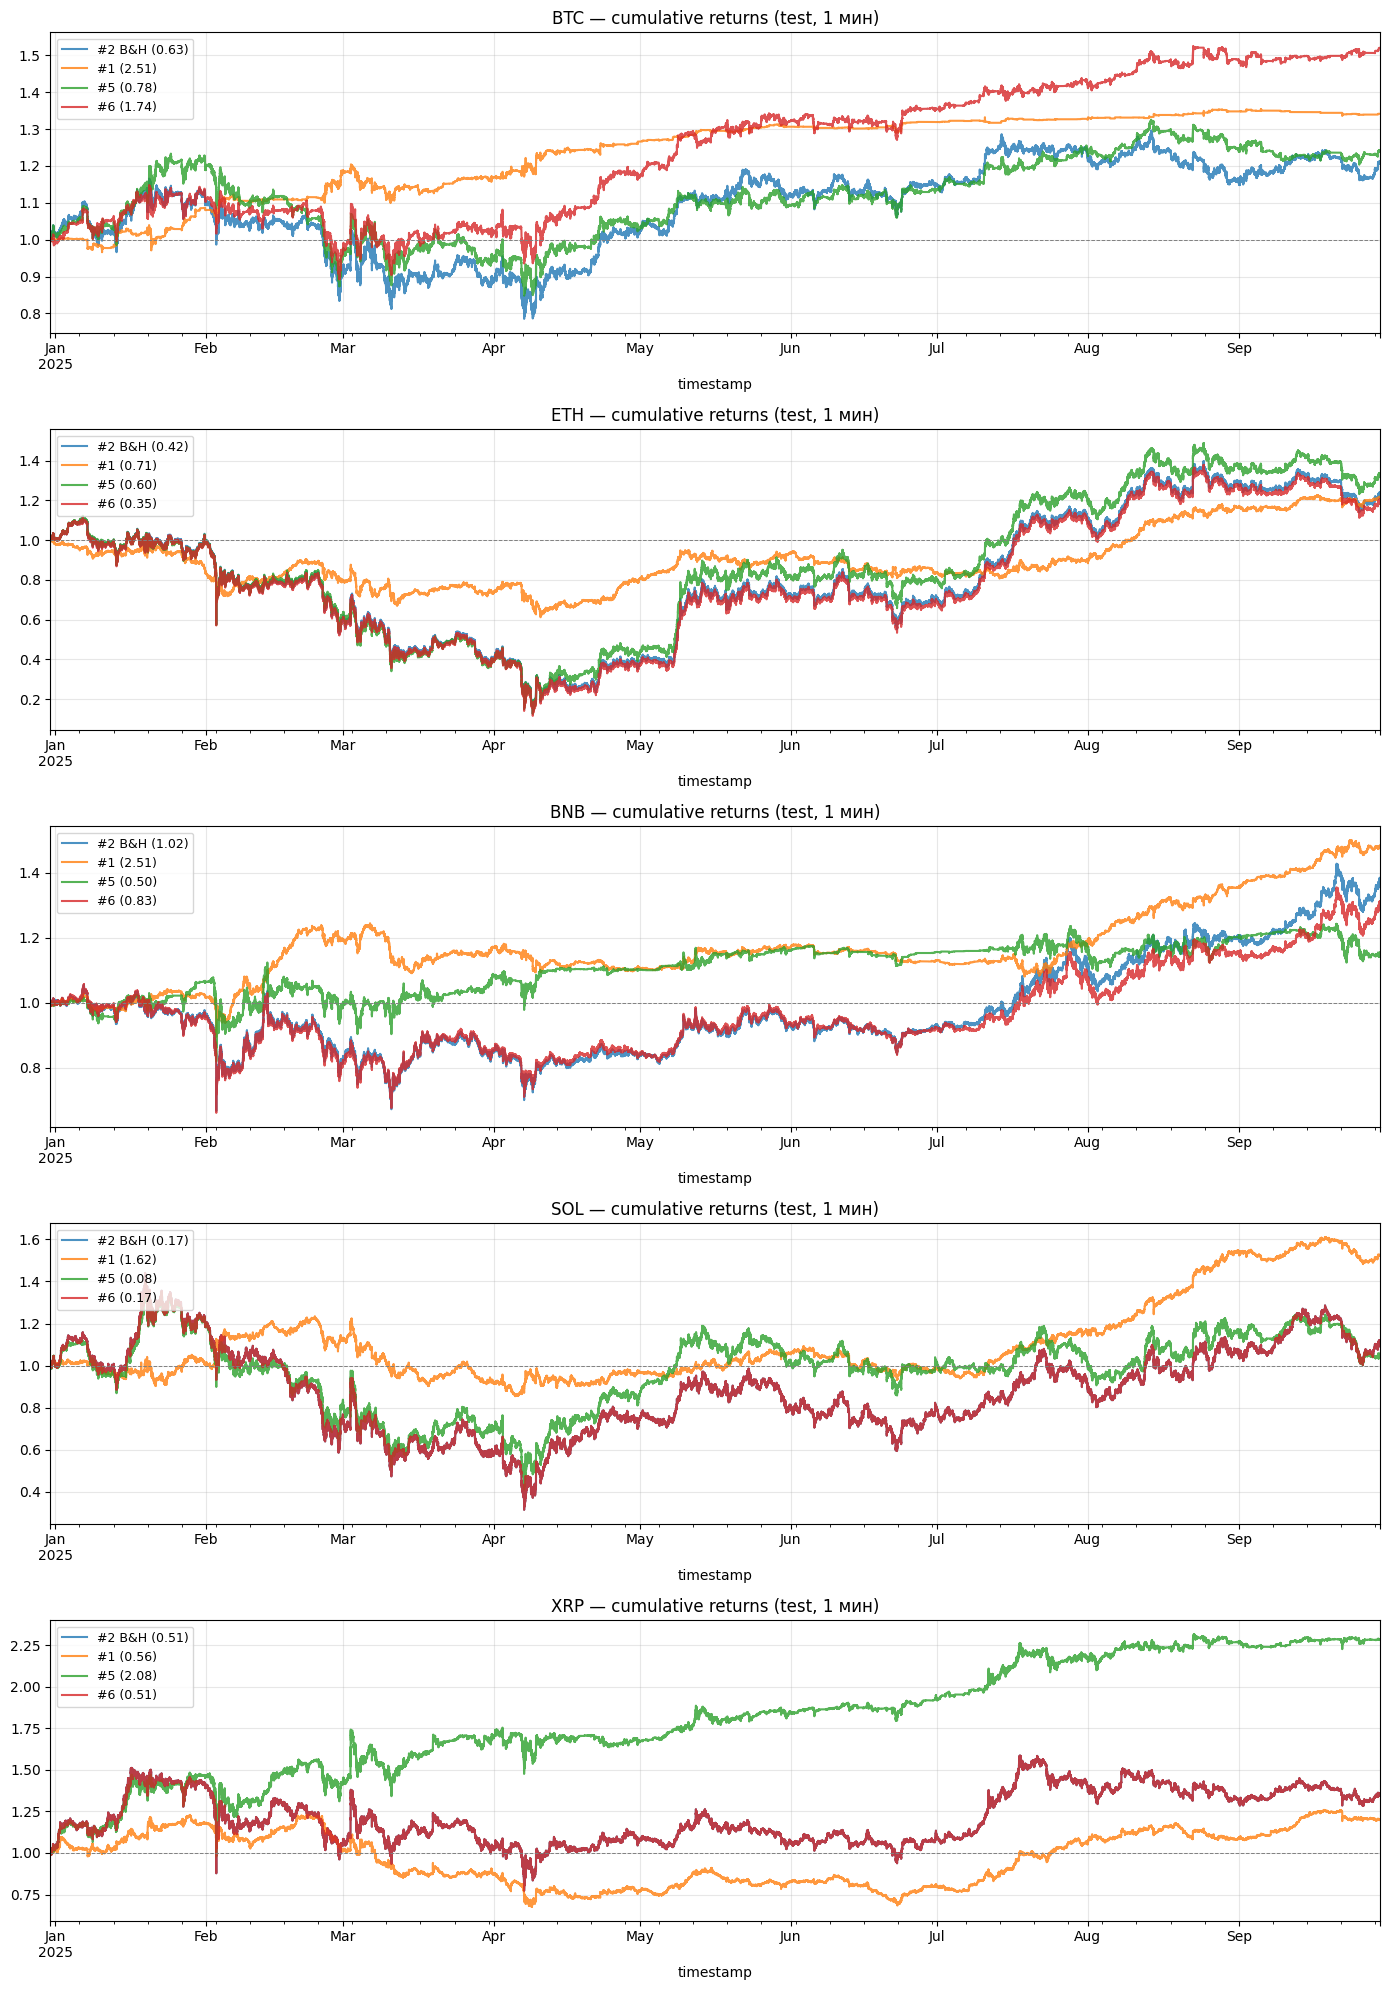

,Asset,AUC s,AUC m,AUC TF,Sharpe BH,Sharpe s,Sharpe m,Sharpe TF
0,BTC,0.526203,0.526549,0.527631,0.633331,2.512878,0.783325,1.740980
1,ETH,0.507244,0.513589,0.509167,0.417240,0.706260,0.596776,0.353317
2,BNB,0.508292,0.514709,0.509554,1.023663,2.506798,0.496443,0.834820
3,SOL,0.500987,0.510091,0.499710,0.167661,1.616985,0.079850,0.167661
4,XRP,0.499219,0.514548,0.499645,0.512046,0.564253,2.083700,0.512046


In [17]:
per_asset = []

for asset in ASSETS:
    a_prefix = f"{asset}__"
    a_feat = [c for c in X_test.columns if str(c).startswith(a_prefix)]
    if not a_feat or len(a_feat) != n_features:
        continue

    a_ybin_col = resolve_y_column(y_test, asset, "y_bin")
    a_yreg_col = resolve_y_column(y_test, asset, "y_reg")
    a_yte_bin = y_test[a_ybin_col].dropna()
    a_yte_reg = y_test[a_yreg_col].dropna()

    a_Xte = X_test[a_feat].loc[a_yte_bin.index]
    a_yte_a = a_yte_bin.values.astype(np.int64)

    a_Xte_single = scaler.transform(a_Xte.values)
    a_Xte_multi = multi_scaler.transform(a_Xte.values)

    ds_single = WindowDataset(a_Xte_single, a_yte_a, WINDOW_SIZE)
    ds_multi = WindowDataset(a_Xte_multi, a_yte_a, WINDOW_SIZE)
    loader_single = DataLoader(ds_single, batch_size=BATCH_SIZE, shuffle=False)
    loader_multi = DataLoader(ds_multi, batch_size=BATCH_SIZE, shuffle=False)

    s_pred, s_true, s_p1 = predict_labels_probs(model, loader_single)
    m_pred_a, m_true_a, m_p1_a = predict_labels_probs(multi_model, loader_multi)
    t_pred, t_true, t_p1 = predict_labels_probs(tf_model, loader_single)

    s_auc = roc_auc_score(s_true, s_p1)
    m_auc_a = roc_auc_score(m_true_a, m_p1_a)
    t_auc = roc_auc_score(t_true, t_p1)

    test_idx = a_Xte.index[WINDOW_SIZE:]
    common_a = test_idx.intersection(a_yte_reg.index)
    act_ret = a_yte_reg.loc[common_a]
    off = len(test_idx) - len(common_a)

    bh_sr = sharpe_ratio(act_ret, PER_YEAR_1M)
    s_strat = pd.Series(s_pred[off:], index=common_a) * act_ret
    m_strat = pd.Series(m_pred_a[off:], index=common_a) * act_ret
    t_strat = pd.Series(t_pred[off:], index=common_a) * act_ret

    per_asset.append({
        "asset": asset,
        "single_auc": s_auc,
        "multi_auc": m_auc_a,
        "tf_auc": t_auc,
        "bh_sharpe": bh_sr,
        "single_sharpe": sharpe_ratio(s_strat, PER_YEAR_1M),
        "multi_sharpe": sharpe_ratio(m_strat, PER_YEAR_1M),
        "tf_sharpe": sharpe_ratio(t_strat, PER_YEAR_1M),
        "bh_cumret": act_ret,
        "single_cumret": s_strat,
        "multi_cumret": m_strat,
        "tf_cumret": t_strat,
    })

df_res = pd.DataFrame(per_asset)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_res))
w = 0.25
ax.bar(x - w, df_res["single_auc"], w, label="#1 SimpleLSTM", color="#4C72B0")
ax.bar(x, df_res["multi_auc"], w, label="#5 Multi-LSTM", color="#DD8452")
ax.bar(x + w, df_res["tf_auc"], w, label="#6 Transformer", color="#55A868")
ax.axhline(0.5, color="gray", ls="--", lw=1)
ax.set_xticks(x)
ax.set_xticklabels(df_res["asset"])
ax.set_ylabel("ROC-AUC")
ax.set_title("ROC-AUC на test по активам (1 мин): №1 / №5 / №6")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))
w2 = 0.2
ax.bar(x - 1.5 * w2, df_res["bh_sharpe"], w2, label="#2 B&H")
ax.bar(x - 0.5 * w2, df_res["single_sharpe"], w2, label="#1")
ax.bar(x + 0.5 * w2, df_res["multi_sharpe"], w2, label="#5")
ax.bar(x + 1.5 * w2, df_res["tf_sharpe"], w2, label="#6")
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(df_res["asset"])
ax.set_ylabel("Sharpe (annualized)")
ax.set_title("Sharpe: №1/№5/№6 vs №2 B&H (1 мин)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

n_a = len(per_asset)
fig, axes = plt.subplots(n_a, 1, figsize=(14, 4 * n_a), sharex=False)
if n_a == 1:
    axes = [axes]
for i, info in enumerate(per_asset):
    ax = axes[i]
    (info["bh_cumret"].cumsum() + 1).plot(ax=ax, label=f"#2 B&H ({info['bh_sharpe']:.2f})", alpha=0.8)
    (info["single_cumret"].cumsum() + 1).plot(ax=ax, label=f"#1 ({info['single_sharpe']:.2f})", alpha=0.8)
    (info["multi_cumret"].cumsum() + 1).plot(ax=ax, label=f"#5 ({info['multi_sharpe']:.2f})", alpha=0.8)
    (info["tf_cumret"].cumsum() + 1).plot(ax=ax, label=f"#6 ({info['tf_sharpe']:.2f})", alpha=0.8)
    ax.axhline(1.0, color="gray", ls="--", lw=0.7)
    ax.set_title(f"{info['asset']} — cumulative returns (test, 1 мин)")
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

summary = df_res[
    ["asset", "single_auc", "multi_auc", "tf_auc", "bh_sharpe", "single_sharpe", "multi_sharpe", "tf_sharpe"]
].copy()
summary.columns = ["Asset", "AUC s", "AUC m", "AUC TF", "Sharpe BH", "Sharpe s", "Sharpe m", "Sharpe TF"]
display(summary)

### Сохранение артефактов (стратегия №1: single-asset LSTM + scaler)

Запись в каталог `models/`: веса эталонной модели и объект `StandardScaler` для воспроизведения инференса.

In [ ]:
out = ROOT / "models"
out.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "input_size": n_features,
        "hidden_size": HIDDEN_SIZE,
        "num_layers": NUM_LAYERS,
        "dropout": DROPOUT,
        "window_size": WINDOW_SIZE,
        "asset": ACTIVE_ASSET,
        "val_roc_auc": float(best_auc),
        "horizon_minutes": 1,
        "strategy": "1_SimpleLSTM_etalon",
    },
    out / "model.pth",
)
with open(out / "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

,model.pth,scaler.pkl
0,/home/dima/Desktop/myrepo/master-coursework/mo...,/home/dima/Desktop/myrepo/master-coursework/mo...


---

# Часть B. Горизонт 15 минут (`y_bin_15m` / `y_reg_15m`)

Та же нумерация стратегий, что в части A: 

**№1** SimpleLSTM (эталон), 

**№2** Buy & Hold, **№3–№6** — LogReg, RF, multi-LSTM, Transformer. 

**Метка:** сумма 15 минутных log-returns вперёд; Sharpe по `y_reg_15m` с `PER_YEAR_15M`.

Ниже: перезагрузка сплитов, построение `y_reg_15m` / `y_bin_15m`, scaler только на train, затем стратегии №1–№6.

### B.1. Перезагрузка данных и построение `y_reg_15m` / `y_bin_15m`

In [19]:
X_train, y_train, X_val, y_val, X_test, y_test = load_splits(DATA_DIR)

ASSETS = ["BTC", "ETH", "BNB", "SOL", "XRP"]
prefix = f"{ACTIVE_ASSET}__"
feat_cols = [c for c in X_train.columns if str(c).startswith(prefix)]
n_features = len(feat_cols)

HORIZON = 15
for asset in ASSETS:
    for df in (y_train, y_val, y_test):
        y_col_r = resolve_y_column(df, asset, "y_reg")
        y_reg_h = df[y_col_r].rolling(window=HORIZON).sum().shift(-(HORIZON - 1))
        df[(asset, f"y_reg_{HORIZON}m")] = y_reg_h
        df[(asset, f"y_bin_{HORIZON}m")] = (y_reg_h > 0).astype(int)

y_col = resolve_y_column(y_train, ACTIVE_ASSET, "y_bin_15m")
Xt = X_train[feat_cols]
Xv = X_val[feat_cols]
Xte = X_test[feat_cols]

yt = y_train[y_col].dropna()
yv = y_val[resolve_y_column(y_val, ACTIVE_ASSET, "y_bin_15m")].dropna()
yte = y_test[resolve_y_column(y_test, ACTIVE_ASSET, "y_bin_15m")].dropna()

Xt = Xt.loc[yt.index]
Xv = Xv.loc[yv.index]
Xte = Xte.loc[yte.index]

scaler_b = StandardScaler()
Xt_s = scaler_b.fit_transform(Xt)
Xv_s = scaler_b.transform(Xv)
Xte_s = scaler_b.transform(Xte)

yt_a = yt.values.astype(np.int64)
yv_a = yv.values.astype(np.int64)
yte_a = yte.values.astype(np.int64)

train_ds = WindowDataset(Xt_s, yt_a, WINDOW_SIZE)
val_ds = WindowDataset(Xv_s, yv_a, WINDOW_SIZE)
test_ds = WindowDataset(Xte_s, yte_a, WINDOW_SIZE)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

counts = np.bincount(train_ds.labels, minlength=2)
w = counts.sum() / (2 * np.maximum(counts, 1))
class_weights = torch.tensor(w, dtype=torch.float32)
display(pd.DataFrame([{"part": "B train", "windows": len(train_ds), "class_counts": counts.tolist()}]))

,part,windows,class_counts
0,B train,348421,"[172709, 175712]"


### B.2. Стратегия №1 — SimpleLSTM (15m), веса + early stopping

In [ ]:
torch.manual_seed(SEED)
np.random.seed(SEED)

model15 = SimpleLSTM(
    input_size=n_features,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(device)
crit15 = nn.CrossEntropyLoss(weight=class_weights.to(device))
opt15 = optim.Adam(model15.parameters(), lr=LR)

best_auc15 = -1.0
best_state15 = None
stale15 = 0
for epoch in range(1, EPOCHS + 1):
    tr_loss = train_epoch(model15, train_loader, crit15, opt15)
    va = roc_auc_logits(model15, val_loader)
    print(f"[15m] epoch {epoch:02d}/{EPOCHS}  loss={tr_loss:.4f}  val_auc={va:.4f}")
    if va > best_auc15:
        best_auc15 = va
        best_state15 = {k: v.cpu().clone() for k, v in model15.state_dict().items()}
        stale15 = 0
    else:
        stale15 += 1
        if stale15 >= PATIENCE:
            print("early stopping")
            break
if best_state15 is not None:
    model15.load_state_dict(best_state15)

print()
print(f"best_val_roc_auc_15m = {best_auc15}")

[15m] epoch 01/30  loss=0.6918  val_auc=0.5092
[15m] epoch 02/30  loss=0.6914  val_auc=0.5080
[15m] epoch 03/30  loss=0.6911  val_auc=0.5142
[15m] epoch 04/30  loss=0.6906  val_auc=0.5070
[15m] epoch 05/30  loss=0.6898  val_auc=0.5045
[15m] epoch 06/30  loss=0.6886  val_auc=0.5146
[15m] epoch 07/30  loss=0.6867  val_auc=0.5085
[15m] epoch 08/30  loss=0.6842  val_auc=0.5107
[15m] epoch 09/30  loss=0.6820  val_auc=0.5052
[15m] epoch 10/30  loss=0.6791  val_auc=0.5071
[15m] epoch 11/30  loss=0.6758  val_auc=0.5094
early stopping


,best_val_roc_auc_15m
0,0.514582


### B.3. №1 на test (15m) и подбор порога на val

ROC-AUC на test и график F1(val) vs порог — в ячейке ниже.

,test_ROC_AUC
0,0.520735


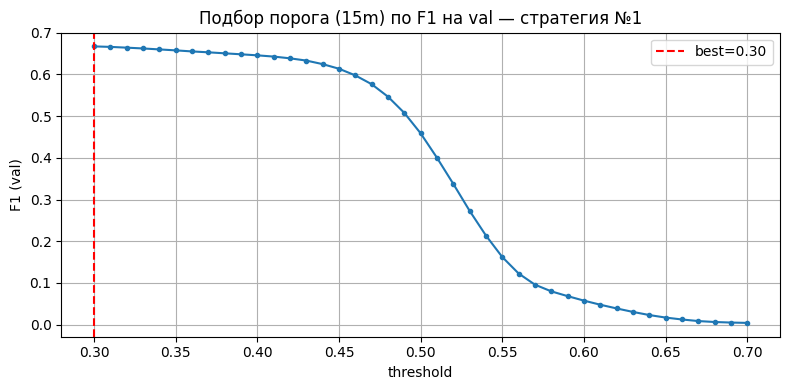

In [ ]:
pred15, y_true15, p1_15 = predict_labels_probs(model15, test_loader)
print()
print(f"test_ROC_AUC = {roc_auc_score(y_true15, p1_15)}")

val_pred15, val_true15, val_p1_15 = predict_labels_probs(model15, val_loader)
thresholds15 = np.arange(0.30, 0.71, 0.01)
f1_val15 = [f1_score(val_true15, (val_p1_15 >= t).astype(int), zero_division=0) for t in thresholds15]
best_thr15 = thresholds15[int(np.argmax(f1_val15))]
test_tuned15 = (p1_15 >= best_thr15).astype(int)

plt.figure(figsize=(8, 4))
plt.plot(thresholds15, f1_val15, marker=".")
plt.axvline(best_thr15, color="red", ls="--", label=f"best={best_thr15:.2f}")
plt.xlabel("threshold")
plt.ylabel("F1 (val)")
plt.title("Подбор порога (15m) по F1 на val — стратегия №1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### B.4. Стратегия №2 — Buy & Hold (15m) и Sharpe №1 vs №2

Фактическая доходность — `y_reg_15m`; годовой множитель — `PER_YEAR_15M`.

,Стратегия,Sharpe (ann.)
0,#2 Buy & Hold,0.651118
1,#1 SimpleLSTM (argmax),-46.275146
2,#1 SimpleLSTM (t=0.30),-1.560194


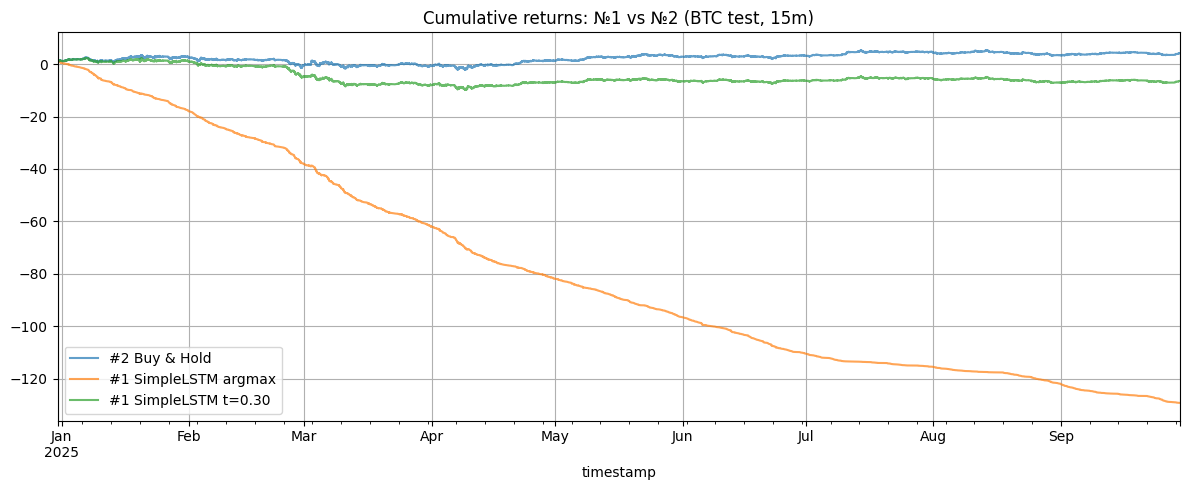

In [22]:
y_reg_col15 = resolve_y_column(y_test, ACTIVE_ASSET, "y_reg_15m")
y_reg_test15 = y_test[y_reg_col15].dropna()
test_idx15 = Xte.index[WINDOW_SIZE:]
common15 = test_idx15.intersection(y_reg_test15.index)
actual15 = y_reg_test15.loc[common15]
off15 = len(test_idx15) - len(common15)

pred_arg_15 = pred15[off15:]
pred_tuned_15 = test_tuned15[off15:]
strat_arg_15 = pd.Series(pred_arg_15, index=common15) * actual15
strat_tuned_15 = pd.Series(pred_tuned_15, index=common15) * actual15

bh15 = sharpe_ratio(actual15, PER_YEAR_15M)
sh_arg15 = sharpe_ratio(strat_arg_15, PER_YEAR_15M)
sh_tuned15 = sharpe_ratio(strat_tuned_15, PER_YEAR_15M)

display(pd.DataFrame([
    ("#2 Buy & Hold", bh15),
    ("#1 SimpleLSTM (argmax)", sh_arg15),
    (f"#1 SimpleLSTM (t={best_thr15:.2f})", sh_tuned15),
], columns=["Стратегия", "Sharpe (ann.)"]))

fig, ax = plt.subplots(figsize=(12, 5))
(actual15.cumsum() + 1).plot(ax=ax, label="#2 Buy & Hold", alpha=0.7)
(strat_arg_15.cumsum() + 1).plot(ax=ax, label="#1 SimpleLSTM argmax", alpha=0.7)
(strat_tuned_15.cumsum() + 1).plot(ax=ax, label=f"#1 SimpleLSTM t={best_thr15:.2f}", alpha=0.7)
ax.set_title("Cumulative returns: №1 vs №2 (BTC test, 15m)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

### B.5. Стратегии №3 и №4 — LogisticRegression и RandomForest (15m)

In [23]:
Xt_agg15, yt_agg15 = aggregate_windows(Xt_s, yt_a, WINDOW_SIZE)
Xte_agg15, yte_agg15 = aggregate_windows(Xte_s, yte_a, WINDOW_SIZE)

lr15 = LogisticRegression(max_iter=500, class_weight="balanced", random_state=SEED)
lr15.fit(Xt_agg15, yt_agg15)
lr_p15 = lr15.predict_proba(Xte_agg15)[:, 1]
lr_pr15 = lr15.predict(Xte_agg15)

rf15 = RandomForestClassifier(
    n_estimators=200, max_depth=8, class_weight="balanced", random_state=SEED, n_jobs=-1
)
rf15.fit(Xt_agg15, yt_agg15)
rf_p15 = rf15.predict_proba(Xte_agg15)[:, 1]

lr_auc15 = roc_auc_score(yte_agg15, lr_p15)
rf_auc15 = roc_auc_score(yte_agg15, rf_p15)

y_reg_15_ser = y_test[resolve_y_column(y_test, ACTIVE_ASSET, "y_reg_15m")]
_idx_15 = Xte.index[WINDOW_SIZE : WINDOW_SIZE + len(lr_p15)]
_ret_lr15 = y_reg_15_ser.reindex(_idx_15).fillna(0.0)
lr_strat15 = pd.Series((lr_p15 >= 0.5).astype(int), index=_idx_15) * _ret_lr15
_ret_rf15 = y_reg_15_ser.reindex(_idx_15).fillna(0.0)
rf_strat15 = pd.Series((rf_p15 >= 0.5).astype(int), index=_idx_15) * _ret_rf15

display(pd.DataFrame([
    ("#3 LogisticRegression", lr_auc15, f1_score(yte_agg15, lr_pr15, zero_division=0)),
    ("#4 RandomForest", rf_auc15, f1_score(yte_agg15, rf15.predict(Xte_agg15), zero_division=0)),
    ("#1 SimpleLSTM (tuned)", roc_auc_score(y_true15, p1_15), f1_score(y_true15, test_tuned15, zero_division=0)),
], columns=["Стратегия", "ROC-AUC", "F1"]))

,Стратегия,ROC-AUC,F1
0,#3 LogisticRegression,0.521769,0.362547
1,#4 RandomForest,0.517213,0.233349
2,#1 SimpleLSTM (tuned),0.520735,0.664607


### B.6. Стратегии №5 и №6 — мультиактивная LSTM и Transformer (15m)

здесь конкатенируются окна по всем активам и подряд идут обучение multi-LSTM и Transformer

 multi] 01/30 loss=0.6921 auc=0.5200
 multi] 02/30 loss=0.6917 auc=0.5215
 multi] 03/30 loss=0.6913 auc=0.5262
 multi] 04/30 loss=0.6908 auc=0.5260
 multi] 05/30 loss=0.6900 auc=0.5247
 multi] 06/30 loss=0.6886 auc=0.5239
 multi] 07/30 loss=0.6869 auc=0.5227
 multi] 08/30 loss=0.6847 auc=0.5213
 TF] 01/30 loss=0.6928 auc=0.5188
 TF] 02/30 loss=0.6917 auc=0.5144
 TF] 03/30 loss=0.6914 auc=0.5163
 TF] 04/30 loss=0.6914 auc=0.5109
 TF] 05/30 loss=0.6910 auc=0.5168
 TF] 06/30 loss=0.6912 auc=0.5161


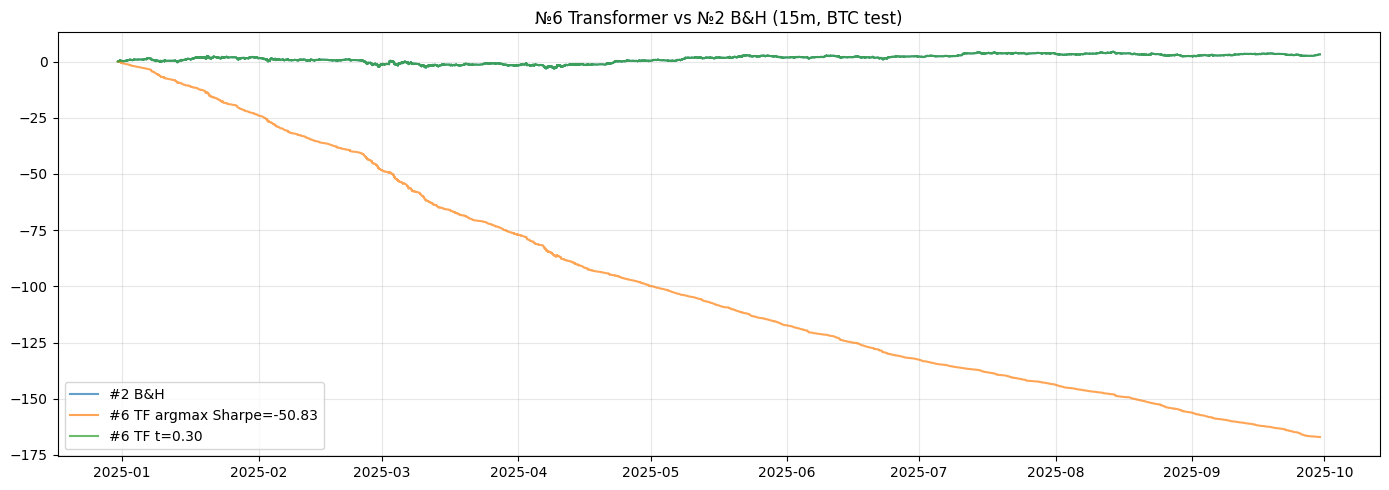

In [24]:
multi_train_X, multi_train_y = [], []
multi_val_X, multi_val_y = [], []
for asset in ASSETS:
    a_prefix = f"{asset}__"
    a_feat = [c for c in X_train.columns if str(c).startswith(a_prefix)]
    if not a_feat:
        continue
    a_ycol = resolve_y_column(y_train, asset, "y_bin_15m")
    a_yt = y_train[a_ycol].dropna()
    a_Xt = X_train[a_feat].loc[a_yt.index]
    a_ycol_v = resolve_y_column(y_val, asset, "y_bin_15m")
    a_yv = y_val[a_ycol_v].dropna()
    a_Xv = X_val[a_feat].loc[a_yv.index]
    multi_train_X.append(a_Xt.values)
    multi_train_y.append(a_yt.values)
    multi_val_X.append(a_Xv.values)
    multi_val_y.append(a_yv.values)

multi_Xt = np.concatenate(multi_train_X, axis=0)
multi_yt = np.concatenate(multi_train_y, axis=0).astype(np.int64)
multi_Xv = np.concatenate(multi_val_X, axis=0)
multi_yv = np.concatenate(multi_val_y, axis=0).astype(np.int64)
del multi_train_X, multi_val_X, multi_train_y, multi_val_y

multi_scaler15 = StandardScaler()
mXt_s = multi_scaler15.fit_transform(multi_Xt)
mXv_s = multi_scaler15.transform(multi_Xv)
del multi_Xt, multi_Xv
gc.collect()

multi_train_ds = WindowDataset(mXt_s, multi_yt, WINDOW_SIZE)
multi_val_ds = WindowDataset(mXv_s, multi_yv, WINDOW_SIZE)
m_tr = DataLoader(multi_train_ds, batch_size=BATCH_SIZE_HEAVY, shuffle=True)
m_va = DataLoader(multi_val_ds, batch_size=BATCH_SIZE_HEAVY, shuffle=False)

mc = np.bincount(multi_train_ds.labels, minlength=2)
mw = mc.sum() / (2 * np.maximum(mc, 1))
mcw = torch.tensor(mw, dtype=torch.float32)

torch.manual_seed(SEED)
multi_model15 = SimpleLSTM(input_size=n_features, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT).to(device)
m_crit = nn.CrossEntropyLoss(weight=mcw.to(device))
m_opt = optim.Adam(multi_model15.parameters(), lr=LR)
m_best, m_state, m_stale = -1.0, None, 0
for epoch in range(1, EPOCHS + 1):
    tl = train_epoch(multi_model15, m_tr, m_crit, m_opt)
    va = roc_auc_logits(multi_model15, m_va)
    print(f"[15m multi] {epoch:02d}/{EPOCHS} loss={tl:.4f} auc={va:.4f}")
    if va > m_best:
        m_best, m_state, m_stale = va, {k: v.cpu().clone() for k, v in multi_model15.state_dict().items()}, 0
    else:
        m_stale += 1
        if m_stale >= PATIENCE:
            break
if m_state is not None:
    multi_model15.load_state_dict(m_state)

del m_tr, m_va, multi_train_ds, multi_val_ds
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

mXte = multi_scaler15.transform(Xte)
m_te_ds = WindowDataset(mXte, yte_a, WINDOW_SIZE)
m_te = DataLoader(m_te_ds, batch_size=BATCH_SIZE_HEAVY, shuffle=False)
m_pred15, m_true15, m_p1_15 = predict_labels_probs(multi_model15, m_te)

m_val_ds_btc = WindowDataset(multi_scaler15.transform(Xv), yv_a, WINDOW_SIZE)
m_val_ld = DataLoader(m_val_ds_btc, batch_size=BATCH_SIZE_HEAVY, shuffle=False)
_, m_v_true, m_v_p1 = predict_labels_probs(multi_model15, m_val_ld)
m_f1s = [f1_score(m_v_true, (m_v_p1 >= t).astype(int), zero_division=0) for t in thresholds15]
m_best_t15 = thresholds15[int(np.argmax(m_f1s))]
m_tuned15 = (m_p1_15 >= m_best_t15).astype(int)
_idx_m15 = Xte.index[WINDOW_SIZE : WINDOW_SIZE + len(m_tuned15)]
_y15 = y_test[resolve_y_column(y_test, ACTIVE_ASSET, "y_reg_15m")]
m_strat_t15 = pd.Series(m_tuned15, index=_idx_m15) * _y15.reindex(_idx_m15).fillna(0.0)

del m_te_ds, m_te, m_val_ds_btc, m_val_ld
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

train_loader_tf15 = DataLoader(train_ds, batch_size=BATCH_SIZE_HEAVY, shuffle=True)
val_loader_tf15 = DataLoader(val_ds, batch_size=BATCH_SIZE_HEAVY, shuffle=False)
test_loader_tf15 = DataLoader(test_ds, batch_size=BATCH_SIZE_HEAVY, shuffle=False)

torch.manual_seed(SEED)
tf15 = TransformerClassifier(input_size=n_features, d_model=64, nhead=4, num_layers=2, dropout=0.1).to(device)
tf_c15 = nn.CrossEntropyLoss(weight=class_weights.to(device))
tf_o15 = optim.Adam(tf15.parameters(), lr=LR)
tf_best, tf_state, tf_stale = -1.0, None, 0
for epoch in range(1, EPOCHS + 1):
    tl = train_epoch(tf15, train_loader_tf15, tf_c15, tf_o15)
    va = roc_auc_logits(tf15, val_loader_tf15)
    print(f"[15m TF] {epoch:02d}/{EPOCHS} loss={tl:.4f} auc={va:.4f}")
    if va > tf_best:
        tf_best, tf_state, tf_stale = va, {k: v.cpu().clone() for k, v in tf15.state_dict().items()}, 0
    else:
        tf_stale += 1
        if tf_stale >= PATIENCE:
            break
if tf_state is not None:
    tf15.load_state_dict(tf_state)

tf_prd15, tf_true15, tf_p1_15 = predict_labels_probs(tf15, test_loader_tf15)
_, tf_v_true, tf_v_p1 = predict_labels_probs(tf15, val_loader_tf15)
best_t_tf15, best_f_tf15 = 0.5, 0.0
for t in thresholds15:
    ft = f1_score(tf_v_true, (tf_v_p1 >= t).astype(int), zero_division=0)
    if ft > best_f_tf15:
        best_t_tf15, best_f_tf15 = t, ft
tf_tuned15 = (tf_p1_15 >= best_t_tf15).astype(int)

tf_pa15 = tf_prd15[off15:]
tf_pt15 = tf_tuned15[off15:]
sh_tf_a15 = sharpe_ratio(pd.Series(tf_pa15, index=common15) * actual15, PER_YEAR_15M)
sh_tf_t15 = sharpe_ratio(pd.Series(tf_pt15, index=common15) * actual15, PER_YEAR_15M)

plt.figure(figsize=(14, 5))
plt.plot(actual15.cumsum(), label="#2 B&H", alpha=0.7)
plt.plot((pd.Series(tf_pa15, index=common15) * actual15).cumsum(), label=f"#6 TF argmax Sharpe={sh_tf_a15:.2f}", alpha=0.7)
plt.plot((pd.Series(tf_pt15, index=common15) * actual15).cumsum(), label=f"#6 TF t={best_t_tf15:.2f}", alpha=0.7)
plt.title("№6 Transformer vs №2 B&H (15m, BTC test)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### B.7. Сводные таблицы (15m), стратегии №1–№6

Сравнение по ROC-AUC / F1 и по Sharpe на горизонте 15 минут.

In [25]:
all15_res = [
    ("#3 LogisticRegression", lr_auc15, f1_score(yte_agg15, lr15.predict(Xte_agg15), zero_division=0)),
    ("#4 RandomForest", rf_auc15, f1_score(yte_agg15, rf15.predict(Xte_agg15), zero_division=0)),
    ("#1 SimpleLSTM (argmax)", roc_auc_score(y_true15, p1_15), f1_score(y_true15, pred15, zero_division=0)),
    (f"#1 SimpleLSTM (t={best_thr15:.2f})", roc_auc_score(y_true15, p1_15), f1_score(y_true15, test_tuned15, zero_division=0)),
    ("#5 Multi-LSTM (argmax)", roc_auc_score(m_true15, m_p1_15), f1_score(m_true15, m_pred15, zero_division=0)),
    (f"#5 Multi-LSTM (t={m_best_t15:.2f})", roc_auc_score(m_true15, m_p1_15), f1_score(m_true15, m_tuned15, zero_division=0)),
    ("#6 Transformer (argmax)", roc_auc_score(tf_true15, tf_p1_15), f1_score(tf_true15, tf_prd15, zero_division=0)),
    (f"#6 Transformer (t={best_t_tf15:.2f})", roc_auc_score(tf_true15, tf_p1_15), f1_score(tf_true15, tf_tuned15, zero_division=0)),
]
all15_sh = [
    ("#2 Buy & Hold", bh15),
    ("#3 LogisticRegression", sharpe_ratio(lr_strat15, PER_YEAR_15M)),
    ("#4 RandomForest", sharpe_ratio(rf_strat15, PER_YEAR_15M)),
    ("#1 SimpleLSTM (argmax)", sh_arg15),
    (f"#1 SimpleLSTM (t={best_thr15:.2f})", sh_tuned15),
    (f"#5 Multi-LSTM (t={m_best_t15:.2f})", sharpe_ratio(m_strat_t15, PER_YEAR_15M)),
    ("#6 Transformer (argmax)", sh_tf_a15),
    (f"#6 Transformer (t={best_t_tf15:.2f})", sh_tf_t15),
]
display(pd.DataFrame(all15_res, columns=["Стратегия", "ROC-AUC", "F1"]))
display(pd.DataFrame(all15_sh, columns=["Стратегия", "Sharpe (ann.)"]))

,Стратегия,ROC-AUC,F1
0,#3 LogisticRegression,0.521769,0.362547
1,#4 RandomForest,0.517213,0.233349
2,#1 SimpleLSTM (argmax),0.520735,0.409178
3,#1 SimpleLSTM (t=0.30),0.520735,0.664607
4,#5 Multi-LSTM (argmax),0.520934,0.488363
5,#5 Multi-LSTM (t=0.38),0.520934,0.666026
6,#6 Transformer (argmax),0.518585,0.435758
7,#6 Transformer (t=0.30),0.518585,0.666031


,Стратегия,Sharpe (ann.)
0,#2 Buy & Hold,0.651118
1,#3 LogisticRegression,1.781689
2,#4 RandomForest,0.742706
3,#1 SimpleLSTM (argmax),-46.275146
4,#1 SimpleLSTM (t=0.30),-1.560194
5,#5 Multi-LSTM (t=0.38),0.652812
6,#6 Transformer (argmax),-50.832670
7,#6 Transformer (t=0.30),0.651118


### B.8. Графики по 5 активам (15m): AUC и Sharpe

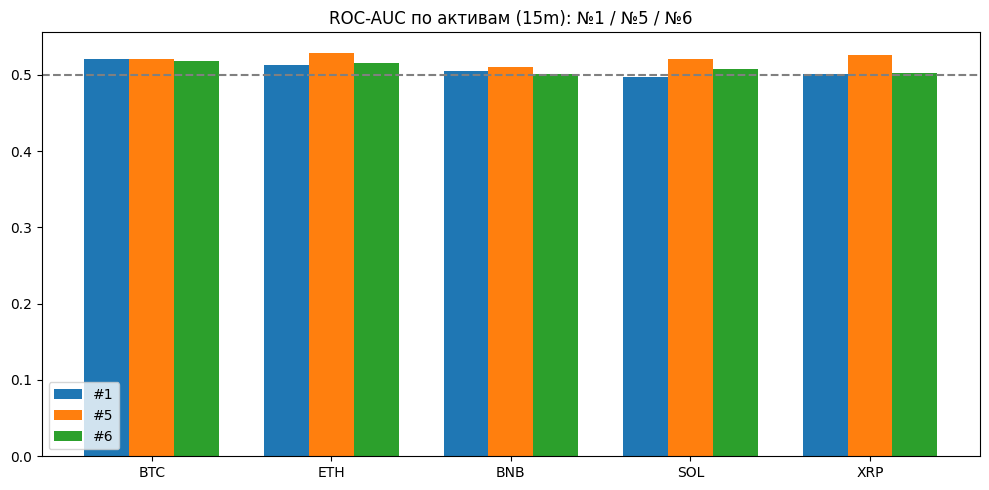

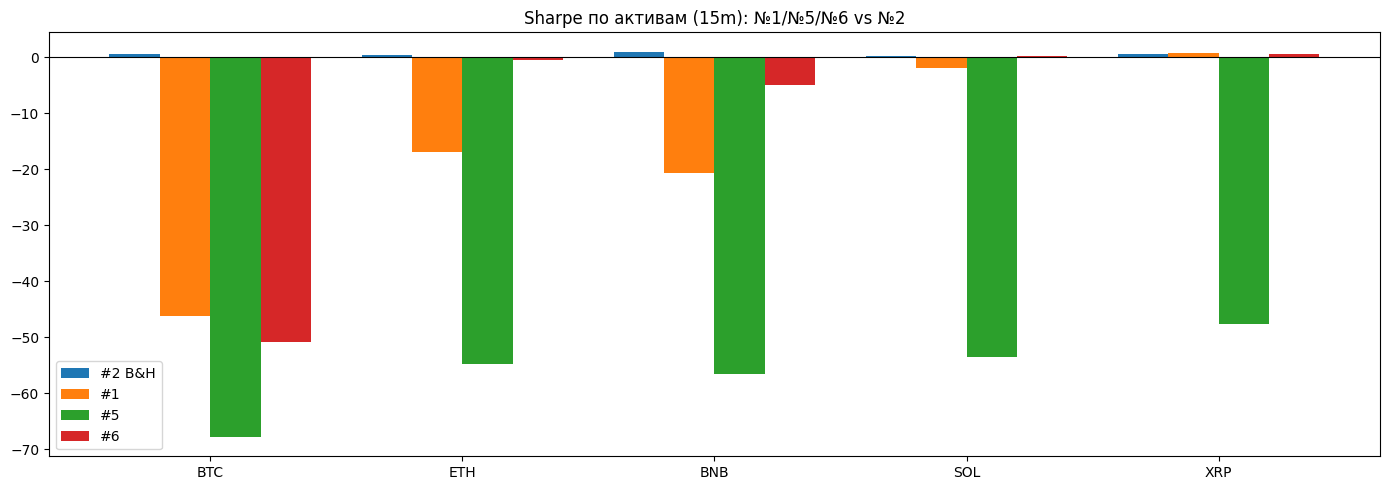

In [26]:
per15 = []
for asset in ASSETS:
    ap = f"{asset}__"
    af = [c for c in X_test.columns if str(c).startswith(ap)]
    if not af or len(af) != n_features:
        continue
    yb = resolve_y_column(y_test, asset, "y_bin_15m")
    yr = resolve_y_column(y_test, asset, "y_reg_15m")
    ybin = y_test[yb].dropna()
    yreg = y_test[yr].dropna()
    Xs = X_test[af].loc[ybin.index]
    ya = ybin.values.astype(np.int64)
    Xss = scaler_b.transform(Xs.values)
    Xsm = multi_scaler15.transform(Xs.values)
    ds_s = WindowDataset(Xss, ya, WINDOW_SIZE)
    ds_m = WindowDataset(Xsm, ya, WINDOW_SIZE)
    ld_s = DataLoader(ds_s, batch_size=BATCH_SIZE_HEAVY, shuffle=False)
    ld_m = DataLoader(ds_m, batch_size=BATCH_SIZE_HEAVY, shuffle=False)
    sp, st, s1 = predict_labels_probs(model15, ld_s)
    mp, mt, m1 = predict_labels_probs(multi_model15, ld_m)
    tp, tt, t1 = predict_labels_probs(tf15, ld_s)
    tix = Xs.index[WINDOW_SIZE:]
    com = tix.intersection(yreg.index)
    act = yreg.loc[com]
    off = len(tix) - len(com)
    per15.append({
        "asset": asset,
        "s_auc": roc_auc_score(st, s1),
        "m_auc": roc_auc_score(mt, m1),
        "t_auc": roc_auc_score(tt, t1),
        "bh": sharpe_ratio(act, PER_YEAR_15M),
        "s_sh": sharpe_ratio(pd.Series(sp[off:], index=com) * act, PER_YEAR_15M),
        "m_sh": sharpe_ratio(pd.Series(mp[off:], index=com) * act, PER_YEAR_15M),
        "t_sh": sharpe_ratio(pd.Series(tp[off:], index=com) * act, PER_YEAR_15M),
    })

df15 = pd.DataFrame(per15)
x = np.arange(len(df15))
w = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, df15["s_auc"], w, label="#1")
ax.bar(x, df15["m_auc"], w, label="#5")
ax.bar(x + w, df15["t_auc"], w, label="#6")
ax.axhline(0.5, color="gray", ls="--")
ax.set_xticks(x)
ax.set_xticklabels(df15["asset"])
ax.set_title("ROC-AUC по активам (15m): №1 / №5 / №6")
ax.legend()
plt.tight_layout()
plt.show()

w2 = 0.2
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - 1.5*w2, df15["bh"], w2, label="#2 B&H")
ax.bar(x - 0.5*w2, df15["s_sh"], w2, label="#1")
ax.bar(x + 0.5*w2, df15["m_sh"], w2, label="#5")
ax.bar(x + 1.5*w2, df15["t_sh"], w2, label="#6")
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(df15["asset"])
ax.set_title("Sharpe по активам (15m): №1/№5/№6 vs №2")
ax.legend()
plt.tight_layout()
plt.show()

---

# Часть C. Тройной барьер (triple-barrier labeling)

Метка в момент времени `i`: по **минутным** log-returns смотрим вперёд `VERTICAL_TB` шагов, начиная с `r[i]`. Волатильность для масштаба барьеров — std предыдущих `VOL_WINDOW_TB` минут.

Первым срабатывает 

**верхний** барьер (`+PT_MULT * σ`) → класс 1; 

**нижний** (`−SL_MULT * σ`) или **тайм-аут** → класс 0.

Обучение: **SimpleLSTM** (как №1), `StandardScaler` только на train, веса классов, early stopping по val ROC-AUC. Оценка: ROC-AUC / F1 на test и Sharpe стратегии long/flat по минутной `y_reg` (как в части A).

### C.1. Данные, метки triple-barrier (BTC), датасеты

In [ ]:
X_train, y_train, X_val, y_val, X_test, y_test = load_splits(DATA_DIR)
prefix = f"{ACTIVE_ASSET}__"
feat_cols = [c for c in X_train.columns if str(c).startswith(prefix)]
n_features = len(feat_cols)
yreg_col = resolve_y_column(y_train, ACTIVE_ASSET, "y_reg")

VOL_WINDOW_TB = 60
PT_MULT = 1.0
SL_MULT = 1.0
VERTICAL_TB = 15

s_tr = y_train[yreg_col].dropna()
s_va = y_val[resolve_y_column(y_val, ACTIVE_ASSET, "y_reg")].dropna()
s_te = y_test[resolve_y_column(y_test, ACTIVE_ASSET, "y_reg")].dropna()

tb_tr = triple_barrier_labels(s_tr, VOL_WINDOW_TB, PT_MULT, SL_MULT, VERTICAL_TB)
tb_va = triple_barrier_labels(s_va, VOL_WINDOW_TB, PT_MULT, SL_MULT, VERTICAL_TB)
tb_te = triple_barrier_labels(s_te, VOL_WINDOW_TB, PT_MULT, SL_MULT, VERTICAL_TB)

ix_tr = tb_tr.dropna().index.intersection(X_train[feat_cols].index)
ix_va = tb_va.dropna().index.intersection(X_val[feat_cols].index)
ix_te = tb_te.dropna().index.intersection(X_test[feat_cols].index)
Xt_tb = X_train[feat_cols].loc[ix_tr]
Xv_tb = X_val[feat_cols].loc[ix_va]
Xte_tb = X_test[feat_cols].loc[ix_te]
yt_tb = tb_tr.loc[ix_tr].astype(np.int64).values
yv_tb = tb_va.loc[ix_va].astype(np.int64).values
yte_tb = tb_te.loc[ix_te].astype(np.int64).values

scaler_tb = StandardScaler()
Xt_s = scaler_tb.fit_transform(Xt_tb)
Xv_s = scaler_tb.transform(Xv_tb)
Xte_s = scaler_tb.transform(Xte_tb)

ds_tr = WindowDataset(Xt_s, yt_tb, WINDOW_SIZE)
ds_va = WindowDataset(Xv_s, yv_tb, WINDOW_SIZE)
ds_te = WindowDataset(Xte_s, yte_tb, WINDOW_SIZE)
ld_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True)
ld_va = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False)
ld_te = DataLoader(ds_te, batch_size=BATCH_SIZE, shuffle=False)

ct = np.bincount(ds_tr.labels, minlength=2)
cw = ct.sum() / (2 * np.maximum(ct, 1))
w_tb = torch.tensor(cw, dtype=torch.float32)

,VOL_WINDOW_TB,PT_MULT,SL_MULT,VERTICAL_TB,train_windows,P(class 1)
0,60,1.0,1.0,15,348347,0.498537


### C.2. SimpleLSTM на triple-barrier, порог на val, Sharpe на test

In [28]:
torch.manual_seed(SEED)
model_tb = SimpleLSTM(input_size=n_features, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT).to(device)
crit_tb = nn.CrossEntropyLoss(weight=w_tb.to(device))
opt_tb = optim.Adam(model_tb.parameters(), lr=LR)
best_auc, best_state, stale = -1.0, None, 0
for epoch in range(1, EPOCHS + 1):
    tl = train_epoch(model_tb, ld_tr, crit_tb, opt_tb)
    va = roc_auc_logits(model_tb, ld_va)
    print(f"[TB] {epoch:02d}/{EPOCHS} loss={tl:.4f} val_auc={va:.4f}")
    if va > best_auc:
        best_auc, best_state, stale = va, {k: v.cpu().clone() for k, v in model_tb.state_dict().items()}, 0
    else:
        stale += 1
        if stale >= PATIENCE:
            break
if best_state is not None:
    model_tb.load_state_dict(best_state)

pred_te, y_true_te, p1_te = predict_labels_probs(model_tb, ld_te)
auc_te = roc_auc_score(y_true_te, p1_te)

idx_te = Xte_tb.index[WINDOW_SIZE : WINDOW_SIZE + len(y_true_te)]
y_reg_te = y_test[resolve_y_column(y_test, ACTIVE_ASSET, "y_reg")].reindex(idx_te).fillna(0.0).values
strat_arg = pd.Series((p1_te >= 0.5).astype(int), index=idx_te) * y_reg_te
bh = sharpe_ratio(pd.Series(y_reg_te, index=idx_te), PER_YEAR_1M)
sh_arg = sharpe_ratio(strat_arg, PER_YEAR_1M)

_, y_val_ld, p1_val = predict_labels_probs(model_tb, ld_va)
idx_val = Xv_tb.index[WINDOW_SIZE : WINDOW_SIZE + len(y_val_ld)]
thresholds = np.linspace(0.05, 0.95, 19)
best_t, best_f = 0.5, -1.0
for t in thresholds:
    f = f1_score(y_val_ld, (p1_val >= t).astype(int), zero_division=0)
    if f > best_f:
        best_t, best_f = t, f
strat_tuned = pd.Series((p1_te >= best_t).astype(int), index=idx_te) * y_reg_te
sh_tuned = sharpe_ratio(strat_tuned, PER_YEAR_1M)

display(pd.DataFrame([
    ("ROC-AUC (test)", auc_te),
    ("F1 argmax", f1_score(y_true_te, pred_te, zero_division=0)),
    (f"F1 tuned (t={best_t:.2f})", f1_score(y_true_te, (p1_te >= best_t).astype(int), zero_division=0)),
    ("Sharpe B&H (test)", bh),
    ("Sharpe argmax", sh_arg),
    (f"Sharpe tuned t={best_t:.2f}", sh_tuned),
], columns=["метрика", "значение"]))

[TB] 01/30 loss=0.6927 val_auc=0.5147
[TB] 02/30 loss=0.6924 val_auc=0.5127
[TB] 03/30 loss=0.6923 val_auc=0.5123
[TB] 04/30 loss=0.6922 val_auc=0.5110
[TB] 05/30 loss=0.6920 val_auc=0.5103
[TB] 06/30 loss=0.6919 val_auc=0.5110


,метрика,значение
0,ROC-AUC (test),0.515179
1,F1 argmax,0.454494
2,F1 tuned (t=0.05),0.661521
3,Sharpe B&H (test),0.636419
4,Sharpe argmax,2.989381
5,Sharpe tuned t=0.05,0.636419


---

# Часть D. Регрессия на суммарный 15-минутный log-return (`y_reg_15m`)

Вместо классификации знака предсказываем **непрерывную** величину forward log-return на 15 минут (как в части B). Модель: **SimpleLSTMReg** (один выход), функция потерь — MSE, early stopping по val MSE.

**Торговля:** на валидации подбираем порог `tau`: long только если `ŷ > tau` (фильтр «ожидаемая доходность выше комиссий/шума»). Sharpe по `y_reg_15m` и `PER_YEAR_15M`, выравнивание индексов как в части B.

### D.1. Построение `y_reg_15m`, датасеты регрессии

In [29]:
X_train, y_train, X_val, y_val, X_test, y_test = load_splits(DATA_DIR)
HORIZON_D = 15
ASSETS_D = ["BTC", "ETH", "BNB", "SOL", "XRP"]
for asset in ASSETS_D:
    for df in (y_train, y_val, y_test):
        y_col_r = resolve_y_column(df, asset, "y_reg")
        y_reg_h = df[y_col_r].rolling(window=HORIZON_D).sum().shift(-(HORIZON_D - 1))
        df[(asset, f"y_reg_{HORIZON_D}m")] = y_reg_h

prefix = f"{ACTIVE_ASSET}__"
feat_cols = [c for c in X_train.columns if str(c).startswith(prefix)]
n_features = len(feat_cols)
y15_col = resolve_y_column(y_train, ACTIVE_ASSET, f"y_reg_{HORIZON_D}m")

Xt = X_train[feat_cols]
Xv = X_val[feat_cols]
Xte = X_test[feat_cols]
yt = y_train[y15_col].dropna()
yv = y_val[resolve_y_column(y_val, ACTIVE_ASSET, f"y_reg_{HORIZON_D}m")].dropna()
yte = y_test[resolve_y_column(y_test, ACTIVE_ASSET, f"y_reg_{HORIZON_D}m")].dropna()
Xt = Xt.loc[yt.index]
Xv = Xv.loc[yv.index]
Xte = Xte.loc[yte.index]

scaler_d = StandardScaler()
Xt_sd = scaler_d.fit_transform(Xt)
Xv_sd = scaler_d.transform(Xv)
Xte_sd = scaler_d.transform(Xte)
yta = yt.values.astype(np.float32)
yva = yv.values.astype(np.float32)
ytea = yte.values.astype(np.float32)

ds_tr_d = WindowDatasetReg(Xt_sd, yta, WINDOW_SIZE)
ds_va_d = WindowDatasetReg(Xv_sd, yva, WINDOW_SIZE)
ds_te_d = WindowDatasetReg(Xte_sd, ytea, WINDOW_SIZE)
ldr_tr = DataLoader(ds_tr_d, batch_size=BATCH_SIZE_HEAVY, shuffle=True)
ldr_va = DataLoader(ds_va_d, batch_size=BATCH_SIZE_HEAVY, shuffle=False)
ldr_te = DataLoader(ds_te_d, batch_size=BATCH_SIZE_HEAVY, shuffle=False)

display(pd.DataFrame([{"part": "D reg 15m", "train_windows": len(ds_tr_d), "y_mean": float(np.mean(yta)), "y_std": float(np.std(yta))}]))

,part,train_windows,y_mean,y_std
0,D reg 15m,348407,0.000012,0.002927


### D.2. SimpleLSTMReg, порог на val, Sharpe на test (15m)

In [30]:
torch.manual_seed(SEED)
model_d = SimpleLSTMReg(input_size=n_features, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT).to(device)
crit_d = nn.MSELoss()
opt_d = optim.Adam(model_d.parameters(), lr=LR)
best_mse, best_state_d, stale_d = float("inf"), None, 0
for epoch in range(1, EPOCHS + 1):
    tl = train_epoch_reg(model_d, ldr_tr, crit_d, opt_d)
    vm = eval_mse_reg(model_d, ldr_va)
    print(f"[Reg15m] {epoch:02d}/{EPOCHS} train_mse={tl:.6f} val_mse={vm:.6f}")
    if vm < best_mse:
        best_mse, best_state_d, stale_d = vm, {k: v.cpu().clone() for k, v in model_d.state_dict().items()}, 0
    else:
        stale_d += 1
        if stale_d >= PATIENCE:
            break
if best_state_d is not None:
    model_d.load_state_dict(best_state_d)

pred_va, y_va_out = predict_reg(model_d, ldr_va)
pred_te, y_te_out = predict_reg(model_d, ldr_te)
mse_te = mean_squared_error(y_te_out, pred_te)
mae_te = mean_absolute_error(y_te_out, pred_te)

idx_va = Xv.index[WINDOW_SIZE : WINDOW_SIZE + len(pred_va)]
idx_te_d = Xte.index[WINDOW_SIZE : WINDOW_SIZE + len(pred_te)]
y_reg_15_va = y_val[resolve_y_column(y_val, ACTIVE_ASSET, f"y_reg_{HORIZON_D}m")].reindex(idx_va).fillna(0.0).values
y_reg_15_te = y_test[resolve_y_column(y_test, ACTIVE_ASSET, f"y_reg_{HORIZON_D}m")].reindex(idx_te_d).fillna(0.0).values

taus = np.unique(np.quantile(pred_va, np.linspace(0.05, 0.95, 25)))
best_tau, best_sh_d = 0.0, -1e18
for tau in taus:
    strat = pd.Series((pred_va > tau).astype(float), index=idx_va) * y_reg_15_va
    sh = sharpe_ratio(strat, PER_YEAR_15M)
    if sh > best_sh_d:
        best_sh_d, best_tau = sh, tau

strat_te = pd.Series((pred_te > best_tau).astype(float), index=idx_te_d) * y_reg_15_te
sh_te_reg = sharpe_ratio(strat_te, PER_YEAR_15M)
bh_d = sharpe_ratio(pd.Series(y_reg_15_te, index=idx_te_d), PER_YEAR_15M)

display(pd.DataFrame([
    ("MSE (test)", mse_te),
    ("MAE (test)", mae_te),
    ("best val MSE", float(best_mse)),
    (f"best tau (val Sharpe)", float(best_tau)),
    ("Sharpe B&H 15m (test)", bh_d),
    (f"Sharpe long if y_hat > tau (test)", sh_te_reg),
], columns=["метрика", "значение"]))

[Reg15m] 01/30 train_mse=0.000048 val_mse=0.000007
[Reg15m] 02/30 train_mse=0.000009 val_mse=0.000008
[Reg15m] 03/30 train_mse=0.000009 val_mse=0.000007
[Reg15m] 04/30 train_mse=0.000009 val_mse=0.000007
[Reg15m] 05/30 train_mse=0.000009 val_mse=0.000007
[Reg15m] 06/30 train_mse=0.000009 val_mse=0.000008
[Reg15m] 07/30 train_mse=0.000009 val_mse=0.000008
[Reg15m] 08/30 train_mse=0.000009 val_mse=0.000007
[Reg15m] 09/30 train_mse=0.000009 val_mse=0.000007
[Reg15m] 10/30 train_mse=0.000009 val_mse=0.000007
[Reg15m] 11/30 train_mse=0.000009 val_mse=0.000007
[Reg15m] 12/30 train_mse=0.000009 val_mse=0.000007
[Reg15m] 13/30 train_mse=0.000009 val_mse=0.000008
[Reg15m] 14/30 train_mse=0.000009 val_mse=0.000008


,метрика,значение
0,MSE (test),0.000005
1,MAE (test),0.001492
2,best val MSE,0.000007
3,best tau (val Sharpe),0.000188
4,Sharpe B&H 15m (test),0.651118
5,Sharpe long if y_hat > tau (test),0.344446


---

# Часть E. Улучшение Triple-Barrier (CNN-1D и RandomForest)

Поскольку тройной барьер (Часть C) показал лучший Sharpe, попробуем улучшить качество предсказаний, используя другие архитектуры:
1. **1D CNN (Сверточная нейросеть)** — отлично выхватывает локальные паттерны (микро-тренды) и часто работает на зашумленных финансовых данных лучше LSTM.
2. **RandomForest на агрегатах** — проверим, сможет ли классический ML на агрегированных окнах побить нейросети на умном таргете.

In [31]:
class Conv1dClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=64, dropout=0.2):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=input_size, out_channels=hidden_size, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(in_channels=hidden_size, out_channels=hidden_size*2, kernel_size=3, padding=1)
        self.global_pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(hidden_size*2, 2)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        # x shape: (batch, seq_len, features) -> need (batch, features, seq_len)
        x = x.transpose(1, 2)
        x = self.pool(self.relu(self.conv1(x)))
        x = self.global_pool(self.relu(self.conv2(x)))
        x = x.squeeze(-1)
        return self.fc(self.dropout(x))

display(pd.DataFrame([{"Модель": "Conv1dClassifier", "Описание": "2 слоя Conv1d + Global Max Pooling"}]))

,Модель,Описание
0,Conv1dClassifier,2 слоя Conv1d + Global Max Pooling


### E.1. Обучение 1D CNN на метках Triple-Barrier

In [32]:
torch.manual_seed(SEED)
model_cnn = Conv1dClassifier(input_size=n_features, hidden_size=64, dropout=DROPOUT).to(device)
crit_cnn = nn.CrossEntropyLoss(weight=w_tb.to(device))
opt_cnn = optim.Adam(model_cnn.parameters(), lr=LR)

best_auc_cnn, best_state_cnn, stale_cnn = -1.0, None, 0
for epoch in range(1, EPOCHS + 1):
    tl = train_epoch(model_cnn, ld_tr, crit_cnn, opt_cnn)
    va = roc_auc_logits(model_cnn, ld_va)
    print(f"[CNN TB] {epoch:02d}/{EPOCHS} loss={tl:.4f} val_auc={va:.4f}")
    if va > best_auc_cnn:
        best_auc_cnn, best_state_cnn, stale_cnn = va, {k: v.cpu().clone() for k, v in model_cnn.state_dict().items()}, 0
    else:
        stale_cnn += 1
        if stale_cnn >= PATIENCE:
            break
if best_state_cnn is not None:
    model_cnn.load_state_dict(best_state_cnn)

pred_te_cnn, y_true_te_cnn, p1_te_cnn = predict_labels_probs(model_cnn, ld_te)
auc_te_cnn = roc_auc_score(y_true_te_cnn, p1_te_cnn)

strat_arg_cnn = pd.Series((p1_te_cnn >= 0.5).astype(int), index=idx_te) * y_reg_te
sh_arg_cnn = sharpe_ratio(strat_arg_cnn, PER_YEAR_1M)

display(pd.DataFrame([
    ("CNN ROC-AUC (test)", auc_te_cnn),
    ("CNN Sharpe argmax", sh_arg_cnn)
], columns=["метрика", "значение"]))

[CNN TB] 01/30 loss=0.6932 val_auc=0.5114
[CNN TB] 02/30 loss=0.6924 val_auc=0.5092
[CNN TB] 03/30 loss=0.6921 val_auc=0.5114
[CNN TB] 04/30 loss=0.6919 val_auc=0.5120
[CNN TB] 05/30 loss=0.6914 val_auc=0.5123
[CNN TB] 06/30 loss=0.6910 val_auc=0.5111
[CNN TB] 07/30 loss=0.6906 val_auc=0.5090
[CNN TB] 08/30 loss=0.6901 val_auc=0.5084
[CNN TB] 09/30 loss=0.6893 val_auc=0.5067
[CNN TB] 10/30 loss=0.6885 val_auc=0.5092


,метрика,значение
0,CNN ROC-AUC (test),0.515539
1,CNN Sharpe argmax,3.920291


### E.2. Обучение RandomForest на метках Triple-Barrier (агрегированные признаки)

In [33]:
Xt_agg_tb, yt_agg_tb = aggregate_windows(Xt_s, yt_tb, WINDOW_SIZE)
Xv_agg_tb, yv_agg_tb = aggregate_windows(Xv_s, yv_tb, WINDOW_SIZE)
Xte_agg_tb, yte_agg_tb = aggregate_windows(Xte_s, yte_tb, WINDOW_SIZE)

rf_tb = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced", random_state=SEED, n_jobs=-1)
rf_tb.fit(Xt_agg_tb, yt_agg_tb)
rf_p1_tb = rf_tb.predict_proba(Xte_agg_tb)[:, 1]

auc_te_rf = roc_auc_score(yte_agg_tb, rf_p1_tb)

idx_te_rf = Xte_tb.index[WINDOW_SIZE : WINDOW_SIZE + len(rf_p1_tb)]
y_reg_te_rf = y_test[resolve_y_column(y_test, ACTIVE_ASSET, "y_reg")].reindex(idx_te_rf).fillna(0.0).values
strat_arg_rf = pd.Series((rf_p1_tb >= 0.5).astype(int), index=idx_te_rf) * y_reg_te_rf
sh_arg_rf = sharpe_ratio(strat_arg_rf, PER_YEAR_1M)

display(pd.DataFrame([
    ("RF ROC-AUC (test)", auc_te_rf),
    ("RF Sharpe argmax", sh_arg_rf)
], columns=["метрика", "значение"]))

,метрика,значение
0,RF ROC-AUC (test),0.511349
1,RF Sharpe argmax,2.470690


---

# Часть F. Трансформер и Ансамблирование

Мы увидели, что 1D CNN дает отличный результат (Sharpe ~3.92). Что если:

**Объединить модели** — усреднить предсказания LSTM, CNN, RandomForest и Transformer. Ансамбли часто дают более стабильный и высокий результат, сглаживая ошибки отдельных моделей.

### F.1. Обучение Transformer на метках Triple-Barrier

In [34]:
torch.manual_seed(SEED)
model_tf_tb = TransformerClassifier(input_size=n_features, d_model=64, nhead=4, num_layers=2, dropout=0.1).to(device)
crit_tf_tb = nn.CrossEntropyLoss(weight=w_tb.to(device))
opt_tf_tb = optim.Adam(model_tf_tb.parameters(), lr=LR)

best_auc_tf, best_state_tf, stale_tf = -1.0, None, 0
for epoch in range(1, EPOCHS + 1):
    tl = train_epoch(model_tf_tb, ld_tr, crit_tf_tb, opt_tf_tb)
    va = roc_auc_logits(model_tf_tb, ld_va)
    print(f"[TF TB] {epoch:02d}/{EPOCHS} loss={tl:.4f} val_auc={va:.4f}")
    if va > best_auc_tf:
        best_auc_tf, best_state_tf, stale_tf = va, {k: v.cpu().clone() for k, v in model_tf_tb.state_dict().items()}, 0
    else:
        stale_tf += 1
        if stale_tf >= PATIENCE:
            break
if best_state_tf is not None:
    model_tf_tb.load_state_dict(best_state_tf)

pred_te_tf, y_true_te_tf, p1_te_tf = predict_labels_probs(model_tf_tb, ld_te)
auc_te_tf = roc_auc_score(y_true_te_tf, p1_te_tf)

strat_arg_tf = pd.Series((p1_te_tf >= 0.5).astype(int), index=idx_te) * y_reg_te
sh_arg_tf = sharpe_ratio(strat_arg_tf, PER_YEAR_1M)

display(pd.DataFrame([
    ("Transformer ROC-AUC (test)", auc_te_tf),
    ("Transformer Sharpe argmax", sh_arg_tf)
], columns=["метрика", "значение"]))

[TF TB] 01/30 loss=0.6941 val_auc=0.5120
[TF TB] 02/30 loss=0.6928 val_auc=0.5129
[TF TB] 03/30 loss=0.6927 val_auc=0.5115
[TF TB] 04/30 loss=0.6926 val_auc=0.5072
[TF TB] 05/30 loss=0.6926 val_auc=0.5103
[TF TB] 06/30 loss=0.6926 val_auc=0.5048
[TF TB] 07/30 loss=0.6928 val_auc=0.5118


,метрика,значение
0,Transformer ROC-AUC (test),0.508574
1,Transformer Sharpe argmax,3.556323


### F.2. Ансамбль (Soft Voting: LSTM + CNN + RF + Transformer)

In [35]:
# Усредняем вероятности класса 1 от всех 4-х моделей
p1_ensemble = (p1_te + p1_te_cnn + rf_p1_tb + p1_te_tf) / 4.0

auc_te_ens = roc_auc_score(y_true_te, p1_ensemble)

strat_arg_ens = pd.Series((p1_ensemble >= 0.5).astype(int), index=idx_te) * y_reg_te
sh_arg_ens = sharpe_ratio(strat_arg_ens, PER_YEAR_1M)

display(pd.DataFrame([
    ("Ensemble ROC-AUC (test)", auc_te_ens),
    ("Ensemble Sharpe argmax", sh_arg_ens)
], columns=["метрика", "значение"]))

,метрика,значение
0,Ensemble ROC-AUC (test),0.515800
1,Ensemble Sharpe argmax,3.620058


### F.3. Сводная таблица по всем моделям на Triple-Barrier (Части C, E, F)

In [36]:
summary_tb = [
    ("Buy & Hold (baseline)", "-", bh),
    ("SimpleLSTM", auc_te, sh_arg),
    ("RandomForest", auc_te_rf, sh_arg_rf),
    ("1D CNN", auc_te_cnn, sh_arg_cnn),
    ("Transformer", auc_te_tf, sh_arg_tf),
    ("Ensemble (Average)", auc_te_ens, sh_arg_ens)
]
df_summary_tb = pd.DataFrame(summary_tb, columns=["Модель", "ROC-AUC", "Sharpe Ratio (ann.)"])
display(df_summary_tb.sort_values(by="Sharpe Ratio (ann.)", ascending=False))

,Модель,ROC-AUC,Sharpe Ratio (ann.)
3,1D CNN,0.515539,3.920291
5,Ensemble (Average),0.5158,3.620058
4,Transformer,0.508574,3.556323
1,SimpleLSTM,0.515179,2.989381
2,RandomForest,0.511349,2.470690
0,Buy & Hold (baseline),-,0.636419


---

# Часть G. Тюнинг гиперпараметров лучшей модели (1D CNN)

В Части E сверточная сеть (1D CNN) показала наилучший результат на метках Triple-Barrier. 
Попробуем выжать из нее еще немного качества с помощью случайного поиска (Random Search) гиперпараметров: размера скрытого слоя, вероятности Dropout и скорости обучения (Learning Rate).

In [ ]:
import random

# Сетка параметров для случайного поиска
hidden_sizes = [32, 64, 128]
dropouts = [0.1, 0.2, 0.3, 0.4]
learning_rates = [1e-3, 5e-4, 1e-4]

NUM_TRIALS = 100
best_val_auc_tune = -1.0
best_params = {}
best_state_tune = None

print("Начинаем случайный поиск гиперпараметров для 1D CNN (Triple-Barrier)...")

for trial in range(1, NUM_TRIALS + 1):
    h_size = random.choice(hidden_sizes)
    drop = random.choice(dropouts)
    lr_tune = random.choice(learning_rates)
    
    print(f"\n--- Trial {trial}/{NUM_TRIALS} | hidden_size={h_size}, dropout={drop}, lr={lr_tune} ---")
    
    torch.manual_seed(SEED)
    model_tune = Conv1dClassifier(input_size=n_features, hidden_size=h_size, dropout=drop).to(device)
    crit_tune = nn.CrossEntropyLoss(weight=w_tb.to(device))
    opt_tune = optim.Adam(model_tune.parameters(), lr=lr_tune)
    
    trial_best_auc, trial_stale = -1.0, 0
    trial_best_state = None
    
    for epoch in range(1, EPOCHS + 1):
        tl = train_epoch(model_tune, ld_tr, crit_tune, opt_tune)
        va = roc_auc_logits(model_tune, ld_va)
        
        if va > trial_best_auc:
            trial_best_auc = va
            trial_best_state = {k: v.cpu().clone() for k, v in model_tune.state_dict().items()}
            trial_stale = 0
        else:
            trial_stale += 1
            if trial_stale >= 3:  # Уменьшим patience для быстрого поиска
                break
    
    print(f"Trial {trial} завершен. Лучший val_auc: {trial_best_auc:.4f}")
    
    if trial_best_auc > best_val_auc_tune:
        best_val_auc_tune = trial_best_auc
        best_params = {'hidden_size': h_size, 'dropout': drop, 'lr': lr_tune}
        best_state_tune = trial_best_state

display(pd.DataFrame([best_params | {"best_val_auc": best_val_auc_tune}]))

Начинаем случайный поиск гиперпараметров для 1D CNN (Triple-Barrier)...

--- Trial 1/100 | hidden_size=128, dropout=0.2, lr=0.001 ---
Trial 1 завершен. Лучший val_auc: 0.5150

--- Trial 2/100 | hidden_size=64, dropout=0.4, lr=0.0005 ---
Trial 2 завершен. Лучший val_auc: 0.5108

--- Trial 3/100 | hidden_size=128, dropout=0.3, lr=0.001 ---
Trial 3 завершен. Лучший val_auc: 0.5117

--- Trial 4/100 | hidden_size=32, dropout=0.3, lr=0.0001 ---
Trial 4 завершен. Лучший val_auc: 0.5152

--- Trial 5/100 | hidden_size=128, dropout=0.1, lr=0.0001 ---
Trial 5 завершен. Лучший val_auc: 0.5123

--- Trial 6/100 | hidden_size=128, dropout=0.3, lr=0.001 ---
Trial 6 завершен. Лучший val_auc: 0.5117

--- Trial 7/100 | hidden_size=64, dropout=0.3, lr=0.0005 ---
Trial 7 завершен. Лучший val_auc: 0.5146

--- Trial 8/100 | hidden_size=32, dropout=0.3, lr=0.001 ---
Trial 8 завершен. Лучший val_auc: 0.5131

--- Trial 9/100 | hidden_size=64, dropout=0.2, lr=0.0005 ---
Trial 9 завершен. Лучший val_auc: 0.5113



,hidden_size,dropout,lr,best_val_auc
0,32,0.4,0.001,0.51715


### G.1. Оценка лучшей модели на тестовой выборке

In [ ]:
# Загружаем лучшие веса в модель с лучшими параметрами
best_model_cnn = Conv1dClassifier(input_size=n_features, hidden_size=best_params['hidden_size'], dropout=best_params['dropout']).to(device)
best_model_cnn.load_state_dict(best_state_tune)

pred_te_tune, y_true_te_tune, p1_te_tune = predict_labels_probs(best_model_cnn, ld_te)
auc_te_tune = roc_auc_score(y_true_te_tune, p1_te_tune)

strat_arg_tune = pd.Series((p1_te_tune >= 0.5).astype(int), index=idx_te) * y_reg_te
sh_arg_tune = sharpe_ratio(strat_arg_tune, PER_YEAR_1M)

display(pd.DataFrame([
    ("Tuned CNN ROC-AUC (test)", auc_te_tune),
    ("Tuned CNN Sharpe argmax", sh_arg_tune)
], columns=["метрика", "значение"]))

---

# Итоговые выводы по всем экспериментам (Части A–F)

Проведенный цикл экспериментов демонстрирует эволюцию подходов к прогнозированию финансовых временных рядов: от наивных постановок к экономически обоснованным.

### 1. Проблема горизонта и наивной разметки (Части A и B)
* **Шум на микро-уровне:** Предсказание на 1 минуту (Часть A) сильно подвержено рыночному шуму.
* **Ловушка бинарного таргета:** Простое увеличение горизонта до 15 минут с предсказанием знака доходности (`y_bin_15m`, Часть B) не решает проблему. Модель пытается торговать каждое микро-движение, что при вероятностях около 0.5 ведет к **катастрофическим убыткам** (Sharpe << 0).

### 2. Смена парадигмы таргета (Части C и D) — лучшие результаты
* **Triple-Barrier Labeling (Часть C):** Переход к разметке по тройному барьеру (Take-Profit, Stop-Loss, Time-out) с учетом волатильности сделал метки экономически осмысленными. Даже при невысоком ROC-AUC (~0.515), Sharpe Ratio радикально вырос (до ~2.5–4.0). Модель научилась предсказывать *траекторию* цены, а не просто финальную точку.
* **Регрессия + Порог (Часть D):** Переход от классификации к регрессии (предсказание величины `y_reg_15m`) позволил ввести порог уверенности `tau`. Отказ от сделок в зоне неопределенности спас стратегию от убытков, характерных для Части B.

### 3. Архитектуры, Ансамблирование и Тюнинг (Части E, F, G)
* **1D CNN:** Сверточные сети отлично проявили себя на зашумленных данных, эффективно выхватывая локальные паттерны (микро-тренды) и показав один из лучших результатов по Sharpe.
* **Transformer:**  хорошо справляется с поиском нелинейных зависимостей на всей ширине окна.
* **Тюнинг гиперпараметров (Часть G):** Оптимизация параметров (Random Search) не дал весомых улучшений. Надо пробовать другими способами улучшить roc-auc\n
* **Ensemble (Ансамбль):** Усреднение предсказаний (Soft Voting) моделей разной природы (LSTM, CNN, RF, Transformer) дает наиболее **стабильный и робастный** результат, взаимно компенсируя ошибки отдельных алгоритмов.

---

# Дальнейшие пути улучшения

Для развития проекта в сторону полноценной алгоритмической торговой системы рекомендуется (судя по работам в интернете):

1. **Meta-Labeling (Мета-разметка):** Использование подхода Маркоса Лопеса де Прадо. Первая (базовая) модель определяет *направление* сделки (Long/Short), а вторая (мета-модель) предсказывает *вероятность успеха* первой модели, определяя *размер позиции* (Position Sizing). Это радикально снижает просадки.
2. **Feature Engineering (Признаки):** 
   * Интеграция данных из книги ордеров (Order Book Imbalance, микроструктура).
   * Мульти-таймфреймовые признаки (одновременная подача агрегатов за 1m, 5m, 15m и 1h).
3. **Кастомная функция потерь (Custom Loss):** Обучение нейросетей не на стандартные CrossEntropy/MSE, а на дифференцируемые аппроксимации Sharpe Ratio или PnL с прямым учетом комиссий.
4. **Учет транзакционных издержек:** Внедрение реалистичных комиссий (Maker/Taker fees) и проскальзывания (Slippage) непосредственно в расчет метрик при подборе порогов на валидации.
5. Подкрутить https://github.com/google-research/timesfm

## Замечания

1. Судя по информации в интернете и от LLM, roc-auc в районе 0.51 уже можно считать "нормальным результатом" для финансовых моделей из-за высокой волатильности крипторынка и неопределённости (например, когда рынок в боковике). Это конечно небольшие значения и мы постараемся ешё выбить результаты. Но помимо сухих цифр из статистки, хотим, чтобы алгоритм и на практике +- соответствовал
2. Некоторые ячейки с выводами (текстовым анализом) были суммаризированы/ LLM